# Importing Packages

In [170]:
# General Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import math
from imblearn.over_sampling import SMOTE        # Handling imbalanced dataset

# Significance Test
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import levene

# For Linear Regression (Model and Metrics)
from sklearn.linear_model import LinearRegression          # Linear Regression  
from sklearn.metrics import mean_squared_error, r2_score   # Linear Regression 
from sklearn.linear_model import LassoCV, Lasso         # Lasso Regression
from sklearn.linear_model import RidgeCV                # Ridge Regression
from sklearn.linear_model import LogisticRegression     # Logistic Regression (Classification)

# Linear Support Vector Classification
from sklearn.svm import LinearSVC

# Principal Component Analysis (PCA) - Feature Dimensionality Reduction
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

In [2]:
seed = np.random.seed(12299542)

# Pre-processing and Exploratory Data Analysis (EDA)

In [3]:
# Reading all the files
tags = pd.read_csv("rmpCapstoneTags.csv", header=None)
ratings = pd.read_csv("rmpCapstoneNum.csv", header =None)
qualitative = pd.read_csv("rmpCapstoneQual.csv", header = None)

## Tags Dataset

In [4]:
# Changing the column names
tags.columns = [
    "Tough Grader", "Good Feedback", "Respected", "Lots to Read", "Participation Matters", 
    "Don't Skip Class", "Lots of Homework", "Inspirational", "Pop Quizzes!", "Accessible", 
    "So Many Papers", "Clear Grading", "Hilarious", "Test Heavy", "Graded by Few Things", 
    "Amazing Lectures", "Caring", "Extra Credit", "Group Projects", "Lecture Heavy"
]

print(tags.shape)
tags.head()

(89893, 20)


,Tough Grader,Good Feedback,Respected,Lots to Read,Participation Matters,Don't Skip Class,Lots of Homework,Inspirational,Pop Quizzes!,Accessible,So Many Papers,Clear Grading,Hilarious,Test Heavy,Graded by Few Things,Amazing Lectures,Caring,Extra Credit,Group Projects,Lecture Heavy
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,1,2,1,0,4,2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,6,3,0,0,2,4,2,1,0,0,0,2,1,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
tags.describe()

,Tough Grader,Good Feedback,Respected,Lots to Read,Participation Matters,Don't Skip Class,Lots of Homework,Inspirational,Pop Quizzes!,Accessible,So Many Papers,Clear Grading,Hilarious,Test Heavy,Graded by Few Things,Amazing Lectures,Caring,Extra Credit,Group Projects,Lecture Heavy
count,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000,89893.000000
mean,0.753763,1.004605,0.698920,0.571646,0.686783,0.656948,0.599724,0.441892,0.141146,0.277352,0.112968,0.550788,0.498726,0.126194,0.118140,0.483764,0.855728,0.402668,0.204198,0.394925
std,1.985588,2.485230,2.123465,1.625783,1.754998,1.803096,1.798637,1.604895,0.797579,1.038501,0.550803,1.464685,2.063489,0.693769,0.501115,1.807547,2.158969,1.660895,0.949802,1.189545
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,112.000000,171.000000,186.000000,82.000000,82.000000,110.000000,141.000000,119.000000,97.000000,63.000000,64.000000,77.000000,224.000000,81.000000,39.000000,136.000000,127.000000,128.000000,92.000000,38.000000


The values for the columns in the tags dataset seem to reflect the sum of tags given to a professor. So, the value for a certain tag can go up to the hundreds

In [6]:
# Checking missing values
tags.isnull().sum()

Tough Grader             0
Good Feedback            0
Respected                0
Lots to Read             0
Participation Matters    0
Don't Skip Class         0
Lots of Homework         0
Inspirational            0
Pop Quizzes!             0
Accessible               0
So Many Papers           0
Clear Grading            0
Hilarious                0
Test Heavy               0
Graded by Few Things     0
Amazing Lectures         0
Caring                   0
Extra Credit             0
Group Projects           0
Lecture Heavy            0
dtype: int64

## Ratings Dataset

In [8]:
# Changing the column names
ratings.columns = [
    "Average Rating", "Average Difficulty", "Number of Ratings", "Received Pepper", 
    "Take Again Proportion", "Online Ratings", "Male", "Female"
]

print(ratings.shape)
ratings.head()

(89893, 8)


,Average Rating,Average Difficulty,Number of Ratings,Received Pepper,Take Again Proportion,Online Ratings,Male,Female
0,5.0,1.5,2.0,0.0,NaN,0.0,0,1
1,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,3.2,3.0,4.0,0.0,NaN,0.0,1,0
3,3.6,3.5,10.0,1.0,NaN,0.0,0,0
4,1.0,5.0,1.0,0.0,NaN,0.0,0,0


In [9]:
ratings.describe()

,Average Rating,Average Difficulty,Number of Ratings,Received Pepper,Take Again Proportion,Online Ratings,Male,Female
count,70004.000000,70004.000000,70004.000000,70004.000000,12160.000000,70004.000000,89893.000000,89893.000000
mean,3.808014,2.864623,5.374721,0.279927,76.417105,0.315611,0.326789,0.301903
std,1.126895,0.991064,8.136628,0.448966,25.011441,1.054728,0.469042,0.459086
min,1.000000,1.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,1.000000,0.000000,60.000000,0.000000,0.000000,0.000000
50%,4.000000,3.000000,3.000000,0.000000,83.000000,0.000000,0.000000,0.000000
75%,4.800000,3.500000,6.000000,1.000000,100.000000,0.000000,1.000000,1.000000
max,5.000000,5.000000,393.000000,1.000000,100.000000,19.000000,1.000000,1.000000


- The average ratings range from 1-5. 
- The `Recieved Pepper`, `Male`, and `Female` columns are binary.
- The `Take Again Proportion` range to 100.

In [10]:
# Checking missing values
ratings.isnull().sum()

Average Rating           19889
Average Difficulty       19889
Number of Ratings        19889
Received Pepper          19889
Take Again Proportion    77733
Online Ratings           19889
Male                         0
Female                       0
dtype: int64

We have a hunch that the missing 19889 in most of the columns are part of the 77733 missing values in the `Take Again Proportion` column. If that is the case, then it might be that those 19889 rmp accounts are accounts with no data. If that is the case, then we can drop those rows because they do not contribute to our analysis.

In [11]:
# Find indices where any of the first columns has missing values
missing_19889_indices = ratings[
    ratings[['Average Rating', 'Average Difficulty', 'Number of Ratings', 'Received Pepper', 'Online Ratings']].isnull().any(axis=1)
].index

# Find indices where 'Take Again Proportion' is missing
missing_77733_indices = ratings[ratings['Take Again Proportion'].isnull()].index

# Check if the 19889 indices are a subset of the 77733 indices
are_19889_in_77733 = missing_19889_indices.isin(missing_77733_indices).all()

print("Are all 19889 rows part of the 77733 rows?", are_19889_in_77733)

Are all 19889 rows part of the 77733 rows? True


So the 19889 missing values are a subset of the 77733 missing values. We can drop them. We will drop them later once we have merged all three datasets.

## Qualitative Dataset

In [12]:
# Changing the column names
qualitative.columns = ["Major/Field", "University", "US State"]

print(qualitative.shape)
qualitative.head()

(89893, 3)


,Major/Field,University,US State
0,Criminal Justice,George Mason University,VA
1,NaN,NaN,NaN
2,English,Alabama State University,AL
3,English,University of Kentucky,KY
4,English,Keiser University,FL


In [13]:
qualitative.describe()

,Major/Field,University,US State
count,70004,70004,70004
unique,1272,3107,89
top,English,Arizona State University,CA
freq,6398,484,8514


In [14]:
# Checking missing values
qualitative.isnull().sum()

Major/Field    19889
University     19889
US State       19889
dtype: int64

## Merging Datasets, handling missing values, and normalization

**Plan:** 
1. Merge the datasets. 
2. The tags dataset is based on raw numbers. A professor with more ratings will have recieved more tags. Therefore, we have normalize the tags.
3. Set a threshold for the average ratings we want to keep based on the number of raw ratings. If we were to keep all average ratings, then we would be keeping ratings that are based on 1 or 2 ratings. Therefore, we **apply a minimum threshold to the raw number of ratings** that determines the average ratings that we keep.


### 1. Merging Datasets and dropping Nan values

We start by merging the dataset because we want to make sure that the rows with NaN that we drop in one dataset are also dropped in the other dataset.

Since all three datasets (`ratings`, `qualitative`, and `tags`) have the same number of records (89893) and are in the **same order**, you can simply use pd.concat() to merge them along the columns.

#### Merging

In [15]:
# Concatenate the datasets along columns
merged_df = pd.concat([ratings, qualitative, tags], axis=1)

# Verify the shape and structure of the merged dataset
print("Shape of the merged dataset:", merged_df.shape)
merged_df.head()

Shape of the merged dataset: (89893, 31)


,Average Rating,Average Difficulty,Number of Ratings,Received Pepper,Take Again Proportion,Online Ratings,Male,Female,Major/Field,University,...,So Many Papers,Clear Grading,Hilarious,Test Heavy,Graded by Few Things,Amazing Lectures,Caring,Extra Credit,Group Projects,Lecture Heavy
0,5.0,1.5,2.0,0.0,NaN,0.0,0,1,Criminal Justice,George Mason University,...,0,0,0,0,0,0,0,0,0,1
1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,3.2,3.0,4.0,0.0,NaN,0.0,1,0,English,Alabama State University,...,0,0,0,0,0,0,0,0,0,0
3,3.6,3.5,10.0,1.0,NaN,0.0,0,0,English,University of Kentucky,...,0,2,1,0,0,0,0,0,1,0
4,1.0,5.0,1.0,0.0,NaN,0.0,0,0,English,Keiser University,...,0,0,0,0,0,0,0,0,0,0


In [16]:
print(merged_df.isnull().sum())

Average Rating           19889
Average Difficulty       19889
Number of Ratings        19889
Received Pepper          19889
Take Again Proportion    77733
Online Ratings           19889
Male                         0
Female                       0
Major/Field              19889
University               19889
US State                 19889
Tough Grader                 0
Good Feedback                0
Respected                    0
Lots to Read                 0
Participation Matters        0
Don't Skip Class             0
Lots of Homework             0
Inspirational                0
Pop Quizzes!                 0
Accessible                   0
So Many Papers               0
Clear Grading                0
Hilarious                    0
Test Heavy                   0
Graded by Few Things         0
Amazing Lectures             0
Caring                       0
Extra Credit                 0
Group Projects               0
Lecture Heavy                0
dtype: int64


#### Dropping the 19889 rows of the in the `ratings` dataset

In [17]:
# Drop the rows corresponding to missing_19889_indices
merged_df = merged_df.drop(missing_19889_indices, axis=0)

# Verify the rows are removed
print("Shape of the DataFrame after dropping rows:", merged_df.shape)

Shape of the DataFrame after dropping rows: (70004, 31)


In [18]:
# Checking missing values
merged_df.isnull().sum()

Average Rating               0
Average Difficulty           0
Number of Ratings            0
Received Pepper              0
Take Again Proportion    57844
Online Ratings               0
Male                         0
Female                       0
Major/Field                  0
University                   0
US State                     0
Tough Grader                 0
Good Feedback                0
Respected                    0
Lots to Read                 0
Participation Matters        0
Don't Skip Class             0
Lots of Homework             0
Inspirational                0
Pop Quizzes!                 0
Accessible                   0
So Many Papers               0
Clear Grading                0
Hilarious                    0
Test Heavy                   0
Graded by Few Things         0
Amazing Lectures             0
Caring                       0
Extra Credit                 0
Group Projects               0
Lecture Heavy                0
dtype: int64

#### `Take Again Proportion` column

We still have 57844 missing values in the `Take Again Proportion` column which is a large portion of the data

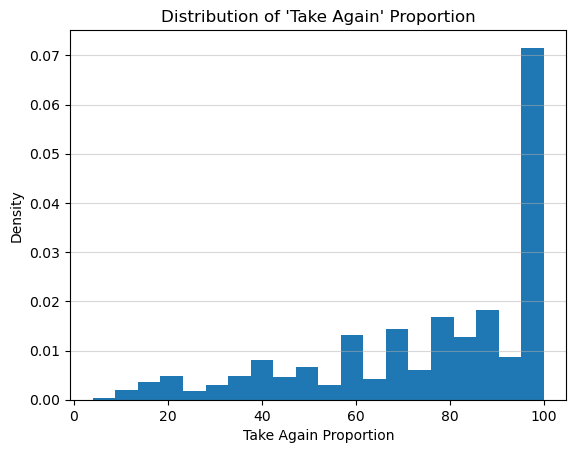

In [19]:
plt.hist(merged_df["Take Again Proportion"], bins =20, density= True)
plt.title("Distribution of 'Take Again' Proportion")
plt.xlabel("Take Again Proportion")
plt.ylabel("Density")
plt.grid(axis="y", alpha = 0.5)
plt.show()

In [20]:
# Filter rows where 'Take Again Proportion' is null
take_again = merged_df.loc[merged_df["Take Again Proportion"].isnull()]

take_again.head(10)

,Average Rating,Average Difficulty,Number of Ratings,Received Pepper,Take Again Proportion,Online Ratings,Male,Female,Major/Field,University,...,So Many Papers,Clear Grading,Hilarious,Test Heavy,Graded by Few Things,Amazing Lectures,Caring,Extra Credit,Group Projects,Lecture Heavy
0,5.0,1.5,2.0,0.0,NaN,0.0,0,1,Criminal Justice,George Mason University,...,0,0,0,0,0,0,0,0,0,1
2,3.2,3.0,4.0,0.0,NaN,0.0,1,0,English,Alabama State University,...,0,0,0,0,0,0,0,0,0,0
3,3.6,3.5,10.0,1.0,NaN,0.0,0,0,English,University of Kentucky,...,0,2,1,0,0,0,0,0,1,0
4,1.0,5.0,1.0,0.0,NaN,0.0,0,0,English,Keiser University,...,0,0,0,0,0,0,0,0,0,0
6,2.3,3.5,2.0,0.0,NaN,0.0,0,0,Biology,Marquette University,...,0,0,0,0,0,0,0,0,0,0
7,2.5,3.0,2.0,0.0,NaN,0.0,1,1,English,Arkansas State University,...,0,0,0,0,0,0,0,0,0,0
8,2.6,4.5,4.0,1.0,NaN,0.0,0,0,Fine Arts,St. Ambrose University,...,0,1,0,0,0,0,0,0,0,1
9,3.0,1.0,1.0,0.0,NaN,0.0,0,1,English,Colorado Mesa University,...,0,0,0,0,0,0,0,0,0,0
10,4.5,3.0,1.0,0.0,NaN,0.0,0,1,Biology,Union County College,...,0,0,0,0,0,0,0,0,0,0
11,3.0,3.0,1.0,0.0,NaN,0.0,0,1,Biology,Louisiana State University of Alexandria,...,0,0,0,0,0,0,0,0,0,0


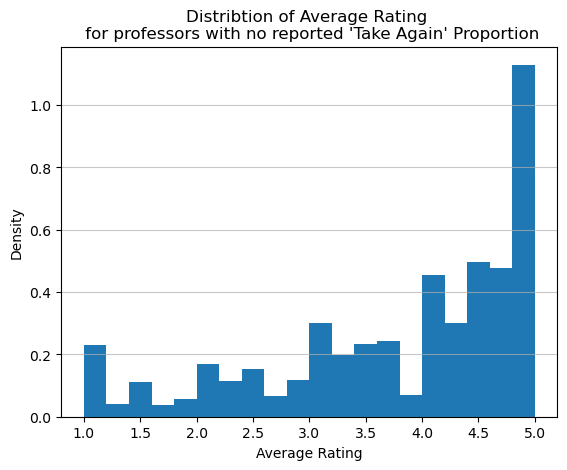

In [21]:
plt.hist(take_again["Average Rating"], bins = 20, density= True)
plt.title("Distribtion of Average Rating \n for professors with no reported 'Take Again' Proportion")
plt.xlabel("Average Rating")
plt.ylabel("Density")
plt.grid(axis = "y", alpha = 0.7)
plt.show()

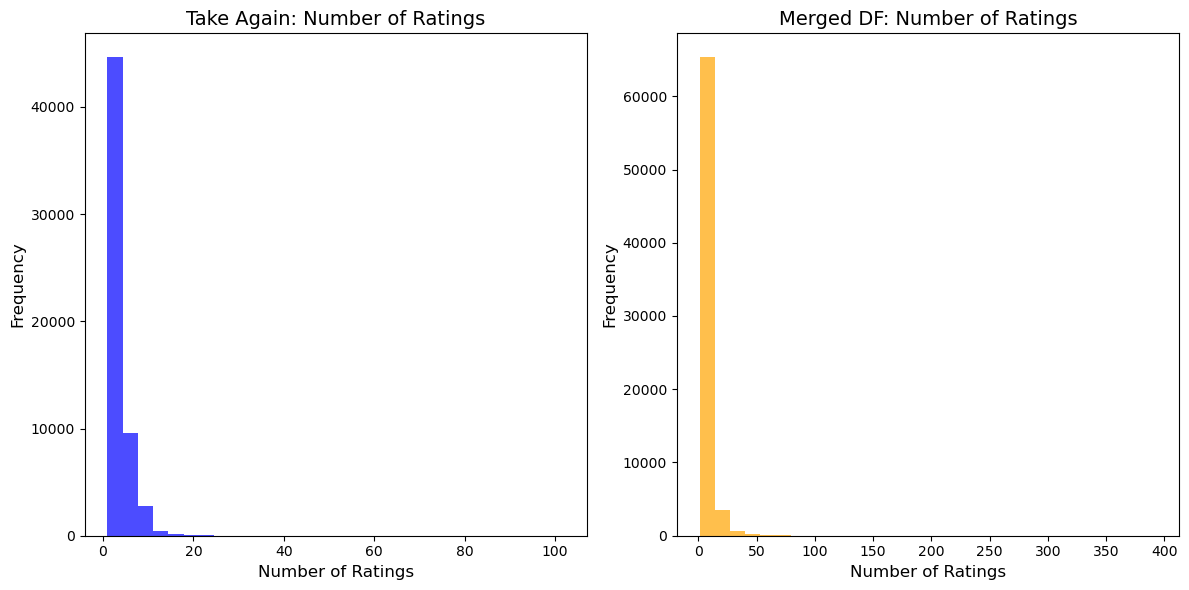

In [22]:
# Create the subplot figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the histogram for 'take_again["Number of Ratings"]' on the first subplot
axes[0].hist(take_again["Number of Ratings"], bins=30, color='blue', alpha=0.7)
axes[0].set_title("Take Again: Number of Ratings", fontsize=14)
axes[0].set_xlabel("Number of Ratings", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

# Plot the histogram for 'merged_df["Number of Ratings"]' on the second subplot
axes[1].hist(merged_df["Number of Ratings"], bins=30, color='orange', alpha=0.7)
axes[1].set_title("Merged DF: Number of Ratings", fontsize=14)
axes[1].set_xlabel("Number of Ratings", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

#### Inconsistencies in the `US State` Column

In [23]:
# Drop the rows that contain US States with length > 2 as they are not in the US and are not relevant to the analysis
states_not_relevant = merged_df[merged_df['US State'].str.len() > 2]
print(f"The number of rows assocaited with non-US cities is: {states_not_relevant['US State'].value_counts().sum()}")
states_not_relevant["US State"].value_counts()

The number of rows assocaited with non-US cities is: 133


US State
LONDON         29
MANCHESTER     14
LANCASHIRE     12
EDINBURGH       9
GLASGOW         8
OXFORDSHIRE     7
HAMPSHIRE       7
KENT            5
FIFE            4
CHESHIRE        4
SURREY          4
CEREDIGION      4
ANTRIM          3
LONDONDERRY     3
Lancashire      2
SOMERSET        2
London          2
DERBYSHIRE      2
EAST SUSSEX     2
SWANSEA         2
WILTSHIRE       1
ESSEX           1
CARDIFF         1
DORSET          1
ANGUS           1
Yorkshire       1
DEVON           1
NORFOLK         1
Name: count, dtype: int64

In [24]:
# Drop the rows that contain US States with length > 2 as they are not in the US and are not relevant to the analysis
merged_df = merged_df.drop(states_not_relevant.index)
print(merged_df.shape)

(69871, 31)


In [25]:
# Checking the number of rows after dropping non-US states
print(f"The number of rows assocaited with non-US cities after dropping is: {merged_df[merged_df['US State'].str.len() > 2].value_counts().sum()}")


The number of rows assocaited with non-US cities after dropping is: 0


#### Inconsistencies between the `Male` and `Female` Columns

- Below is the case when the professor is not male or female. In our analysis, we consider those professors as non-binary

In [26]:
non_binary = merged_df[(merged_df["Male"] == 0) & (merged_df["Female"] == 0)]
print(non_binary.shape)

(15664, 31)


- On the other hand, when a professor is both male *and* female, we drop those rows because those two genders are mutually exclusive.

In [27]:
no_gender = merged_df[(merged_df["Male"] == 1) & (merged_df["Female"] == 1)]
print(no_gender.shape)

(2207, 31)


In [28]:
# Identify rows where both Male and Female are 1
inconsistent_gender = (merged_df["Male"] == 1) & (merged_df["Female"] == 1)

# Drop these rows from merged_df
merged_df = merged_df[~inconsistent_gender]
print(merged_df.shape)


(67664, 31)


In [29]:
merged_df["Number of Ratings"].value_counts().head(20)

Number of Ratings
1.0     16962
2.0     11415
3.0      8323
4.0      6381
5.0      4653
6.0      3611
7.0      2759
8.0      2191
9.0      1831
10.0     1455
11.0     1089
12.0      932
13.0      805
14.0      699
15.0      520
16.0      509
17.0      395
18.0      356
19.0      289
20.0      275
Name: count, dtype: int64

### 2. Normalization: 
The tags dataset is based on raw numbers. A professor with more ratings will have recieved more tags. Therefore, we have normalize the tags.

Since we are normalizing dividing the number of tags by the total number of ratings, we have to make sure of two things: (1) not dividing by zero (so making sure there are no 0 values in the total number of ratings) and (2) not dividing by NaN since that will result in an NaN (So making sure there are no NaN values in the total number of ratings)

The minimum number of total ratings is 1 which alliviates the first concern. Additionally, there are no NaN values in the total number of values since we have dropped them.

In [30]:
# Extract the tags columns
tags_columns = merged_df.iloc[:, 11:31]

# Extract the 'Number of Ratings' column
total_ratings = merged_df['Number of Ratings']

# Normalize the tags by dividing each tag column by the total number of ratings
normalized_tags = tags_columns.div(total_ratings, axis=0)

# Explicitly update column data types to float64 before assignment just we don't get a warning
# The original data in the tags data were integers
for col in tags_columns.columns:
    merged_df[col] = normalized_tags[col].astype(float)

In [31]:
# Verify the normalization
merged_df.iloc[:, 11:].head()

,Tough Grader,Good Feedback,Respected,Lots to Read,Participation Matters,Don't Skip Class,Lots of Homework,Inspirational,Pop Quizzes!,Accessible,So Many Papers,Clear Grading,Hilarious,Test Heavy,Graded by Few Things,Amazing Lectures,Caring,Extra Credit,Group Projects,Lecture Heavy
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.500000
2,0.500000,0.250000,0.500000,0.250000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
3,0.600000,0.300000,0.000000,0.000000,0.200000,0.400000,0.200000,0.100000,0.0,0.000000,0.0,0.200000,0.100000,0.0,0.0,0.0,0.000000,0.0,0.100000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000
5,0.363636,0.590909,0.045455,0.136364,0.090909,0.136364,0.090909,0.045455,0.0,0.136364,0.0,0.318182,0.136364,0.0,0.0,0.0,0.136364,0.0,0.045455,0.136364


### 3. Thershold setting for number of ratings that determine the average ratings we keep

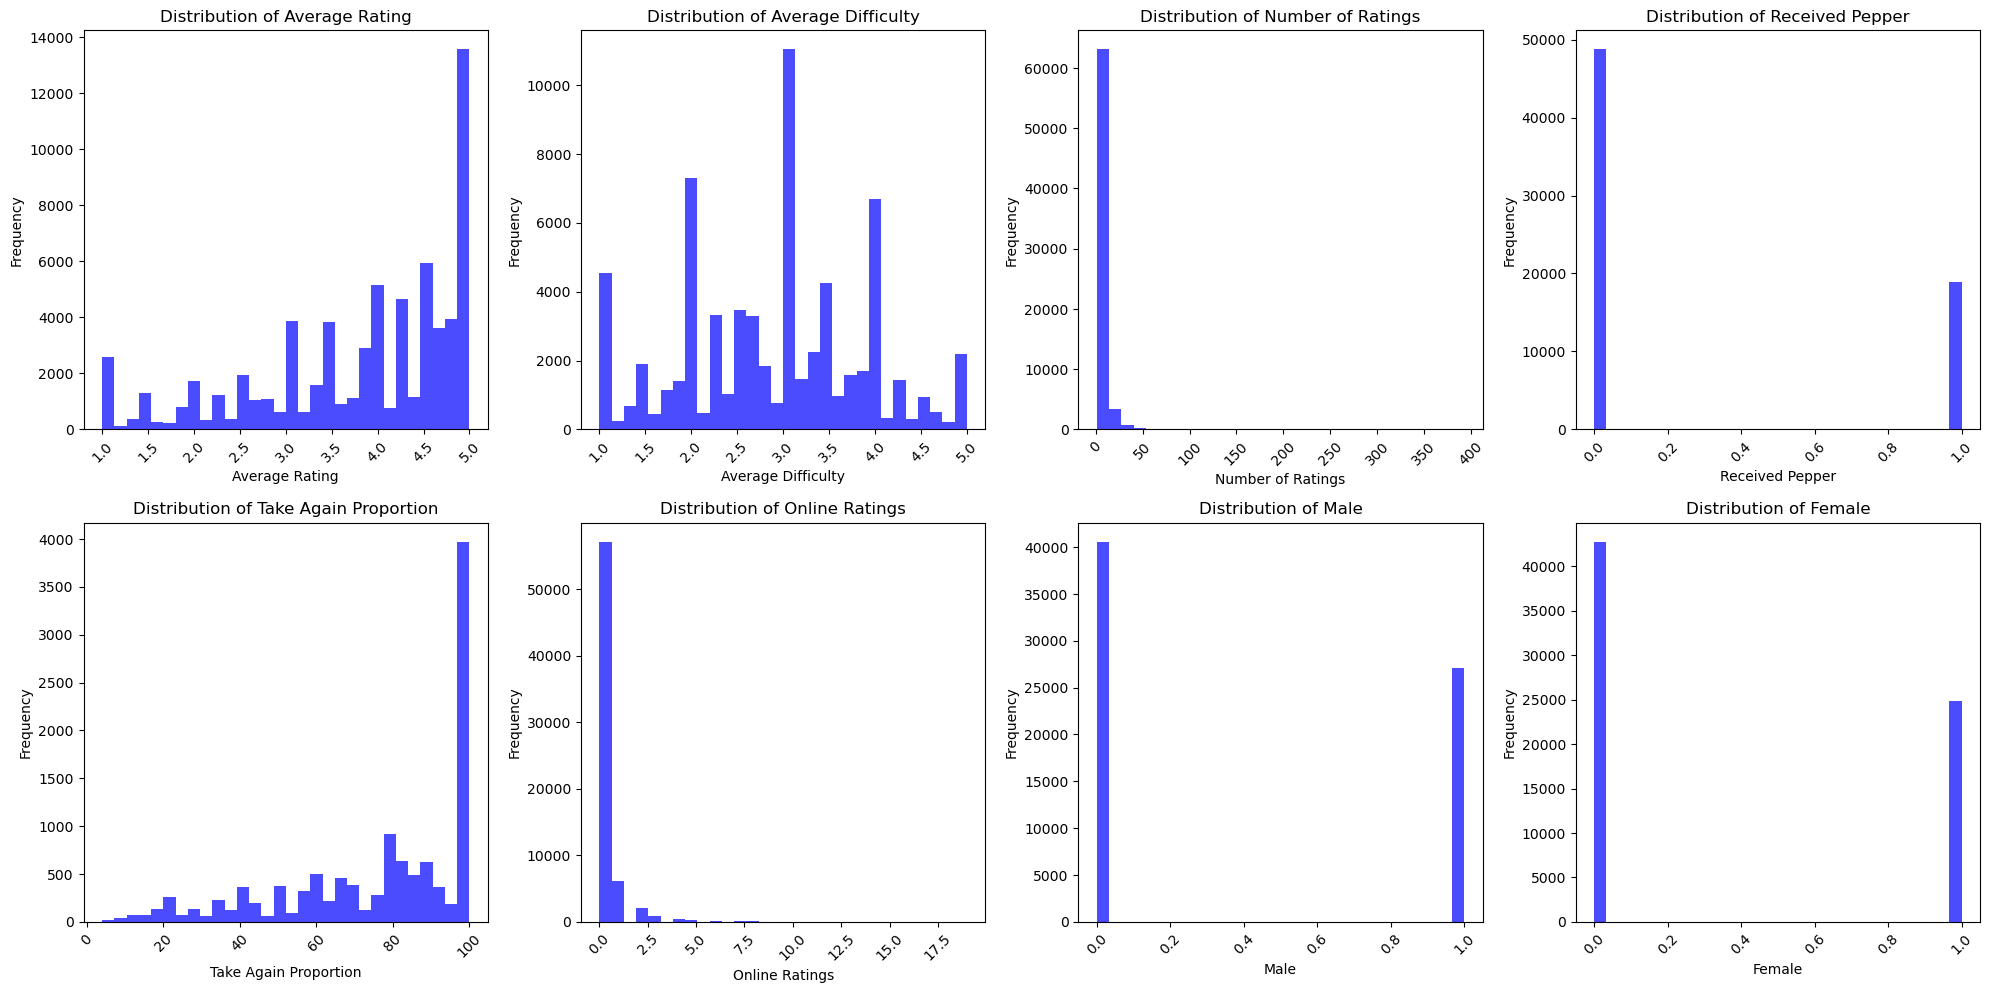

In [32]:
# Select the first 8 columns
columns_to_visualize = merged_df.iloc[:, :8]

# Number of columns to visualize
num_columns = len(columns_to_visualize.columns)

# Create subplots: 2 rows, 4 columns for a total of 8 plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Flatten axes for easier iteration

# Loop through columns and corresponding subplot axes
for i, column in enumerate(columns_to_visualize.columns):
    ax = axes[i]
    
    # Numerical columns: Use histogram
    if pd.api.types.is_numeric_dtype(columns_to_visualize[column]):
        ax.hist(columns_to_visualize[column].dropna(), bins=30, color="blue", alpha=0.7)
        ax.set_title(f"Distribution of {column}", fontsize=12)
        ax.set_xlabel(column, fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
    
    # Categorical or boolean columns: Use bar chart
    elif pd.api.types.is_categorical_dtype(columns_to_visualize[column]) or \
         pd.api.types.is_bool_dtype(columns_to_visualize[column]):
        columns_to_visualize[column].value_counts().plot(kind='bar', ax=ax, color="orange", alpha=0.7)
        ax.set_title(f"Bar Chart of {column}", fontsize=12)
        ax.set_xlabel(column, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
    
    # Rotate x-axis labels for readability
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplot axes (if there are fewer than 8 columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

In [33]:
# Summary statistics 
merged_df["Number of Ratings"].describe()

count    67664.000000
mean         5.394316
std          8.197641
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        393.000000
Name: Number of Ratings, dtype: float64

We use **Bayesian Average Rating** instead of average rating. The Bayesian average incorporates a prior belief (e.g., the overall average rating across all professors) and adjusts individual average ratings based on the number of ratings they have received. We are using the formula

$$
\text{Bayesian Average Rating} = \frac{\mu \cdot v + n \cdot \bar{r}}{v + n}
$$

Where

- $\mu$ is the prior mean (overall average rating).
- $v$ is the virtual count (strength of the prior).
- $n$ is the number of ratings for the professor.
- $\bar{r}$ is the professor’s average rating.


If a professor who previously had no reviews recieves one 5-star review, her average review will be the best there is, however, we would not want to immediately rank her at the top based on one review. Similarly, if a professor who previously haf no reviews recieves a one 1-star review, he will have a bad review, however, we would not want to immediately rank him at the bottom.

Instead, a Bayesian average starts with an idea of the average score a professor receive, in our case, starting out with the mean of average ratings (~3.8). We then treat each professor as starting with a 3.8 average rating before any real reviews are submitted. Each good review for a professor will then increase the average rating a bit and each bad review will decrease the average rating a bit. That is, a professor with only a few reviews will not rank extremly high or extremely low.

#### (a)Bayesian Average Rating

In [34]:
# Calculating the prior
overall_mean = merged_df['Average Rating'].mean()

# Calculating the virtual count
virtual_count = merged_df['Number of Ratings'].mean()

# Finally, calculating the Bayesian average
merged_df['Bayesian Average Rating'] = (
    (overall_mean * virtual_count + merged_df['Average Rating'] * merged_df['Number of Ratings']) /
    (virtual_count + merged_df['Number of Ratings'])
)

In [35]:
overall_mean

3.805419425396074

In [36]:
# Exploring the data
avg_ratings = merged_df[["Average Rating", "Bayesian Average Rating", "Number of Ratings"]]

avg_ratings.head(10)

,Average Rating,Bayesian Average Rating,Number of Ratings
0,5.0,4.128527,2.0
2,3.2,3.547638,4.0
3,3.6,3.671981,10.0
4,1.0,3.366683,1.0
5,3.5,3.560141,22.0
6,2.3,3.398237,2.0
8,2.6,3.292165,4.0
9,3.0,3.679461,1.0
10,4.5,3.914044,1.0
11,3.0,3.679461,1.0


In [37]:
# Looking at the difference in average rating and Bayesian average for professors with
# number of ratings less than or equal to 5
avg_ratings[avg_ratings["Number of Ratings"] <=5].head(20)

,Average Rating,Bayesian Average Rating,Number of Ratings
0,5.0,4.128527,2.0
2,3.2,3.547638,4.0
4,1.0,3.366683,1.0
6,2.3,3.398237,2.0
8,2.6,3.292165,4.0
9,3.0,3.679461,1.0
10,4.5,3.914044,1.0
11,3.0,3.679461,1.0
12,2.5,3.601266,1.0
18,4.2,3.946436,3.0


In [38]:
# The mean of both average ratings are similar, however, their distributions are quite different as seen below
print(np.mean(avg_ratings["Average Rating"]))
print(np.mean(avg_ratings["Bayesian Average Rating"]))

3.805419425396074
3.813030280576254


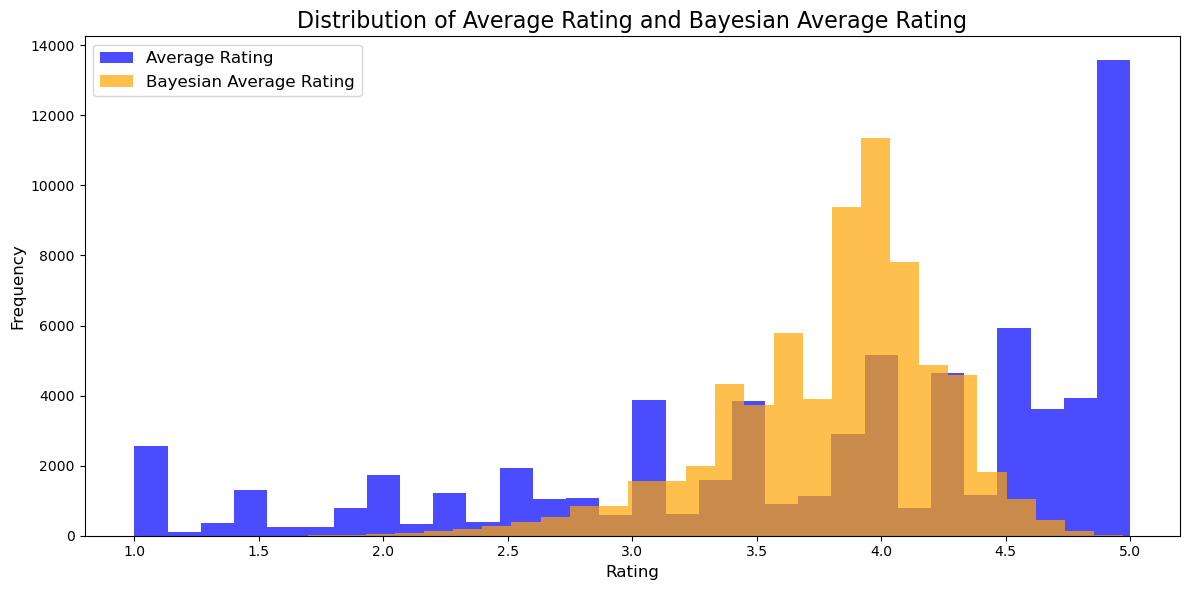

In [39]:
# Create the subplot figure
plt.figure(figsize=(12, 6))

# Plot Average Rating
plt.hist(merged_df["Average Rating"], bins=30, alpha=0.7, label="Average Rating", color="blue")

# Plot Bayesian Average Rating
plt.hist(merged_df["Bayesian Average Rating"], bins=30, alpha=0.7, label="Bayesian Average Rating", color="orange")

# Add title, labels, and legend
plt.title("Distribution of Average Rating and Bayesian Average Rating", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

Notice from the Figure above that the original average rating distribution shows shows a peak at 5 and a jump at 1 which is due to professors' ratings with small samples.

The Bayesian average ratings, on the other hand, smooth out these extremes by pulling them towards the overall mean. Essentially, the Bayesian prior adjusts ratings with low sample sizes toward the global average.

#### (b) Bayesian Average Difficulty

In [40]:
# Calculating the prior
overall_mean = merged_df['Average Difficulty'].mean()

# Calculating the virtual count
virtual_count = merged_df['Number of Ratings'].mean()

# Correcting the Bayesian calculation for difficulty
merged_df['Bayesian Average Difficulty'] = (
    (overall_mean * virtual_count + merged_df['Average Difficulty'] * merged_df['Number of Ratings']) /
    (virtual_count + merged_df['Number of Ratings'])
)

In [41]:
# Exploring the data
avg_difficulty = merged_df[["Average Difficulty", "Bayesian Average Difficulty", "Number of Ratings"]]

avg_difficulty.head(10)

,Average Difficulty,Bayesian Average Difficulty,Number of Ratings
0,1.5,2.497248,2.0
2,3.0,2.923623,4.0
3,3.5,3.278187,10.0
4,5.0,3.200568,1.0
5,3.3,3.214734,22.0
6,3.5,3.038204,2.0
8,4.5,3.562307,4.0
9,1.0,2.575012,1.0
10,3.0,2.887790,1.0
11,3.0,2.887790,1.0


In [42]:
# Looking at the difference in average difficulty and Bayesian average for professors with
# number of ratings less than or equal to 5
avg_difficulty[avg_difficulty["Number of Ratings"] <=5].head(20)

,Average Difficulty,Bayesian Average Difficulty,Number of Ratings
0,1.5,2.497248,2.0
2,3.0,2.923623,4.0
4,5.0,3.200568,1.0
6,3.5,3.038204,2.0
8,4.5,3.562307,4.0
9,1.0,2.575012,1.0
10,3.0,2.887790,1.0
11,3.0,2.887790,1.0
12,5.0,3.200568,1.0
18,1.7,2.449925,3.0


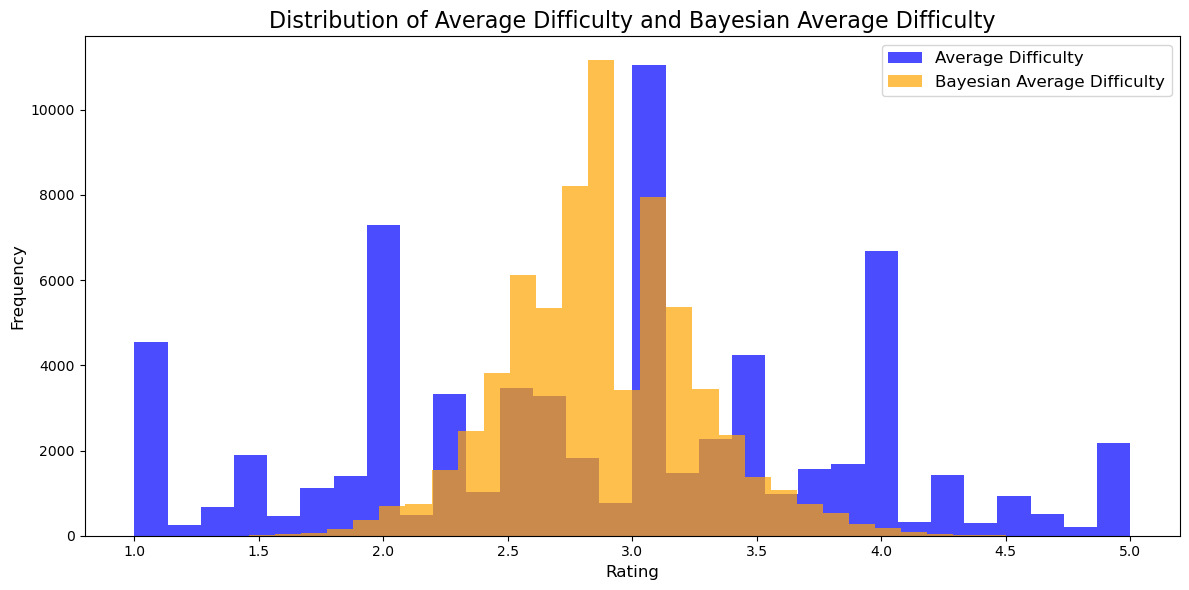

In [43]:
# Create the subplot figure
plt.figure(figsize=(12, 6))

# Plot Average Rating
plt.hist(merged_df["Average Difficulty"], bins=30, alpha=0.7, label="Average Difficulty", color="blue")

# Plot Bayesian Average Rating
plt.hist(merged_df["Bayesian Average Difficulty"], bins=30, alpha=0.7, label="Bayesian Average Difficulty", color="orange")

# Add title, labels, and legend
plt.title("Distribution of Average Difficulty and Bayesian Average Difficulty", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [44]:
# Comparing the averages to the Bayesian averages for those with only one rating

merged_df[merged_df["Number of Ratings"] == 1][["Average Rating", "Bayesian Average Rating", 
                                                "Average Difficulty", "Bayesian Average Difficulty",
                                                "Number of Ratings"]].head(20)

,Average Rating,Bayesian Average Rating,Average Difficulty,Bayesian Average Difficulty,Number of Ratings
4,1.0,3.366683,5.0,3.200568,1.0
9,3.0,3.679461,1.0,2.575012,1.0
10,4.5,3.914044,3.0,2.887790,1.0
11,3.0,3.679461,3.0,2.887790,1.0
12,2.5,3.601266,5.0,3.200568,1.0
24,3.5,3.757655,2.0,2.731401,1.0
28,3.5,3.757655,5.0,3.200568,1.0
29,5.0,3.992239,1.0,2.575012,1.0
30,5.0,3.992239,1.0,2.575012,1.0
33,4.0,3.835850,2.0,2.731401,1.0


## Correlation Matrix

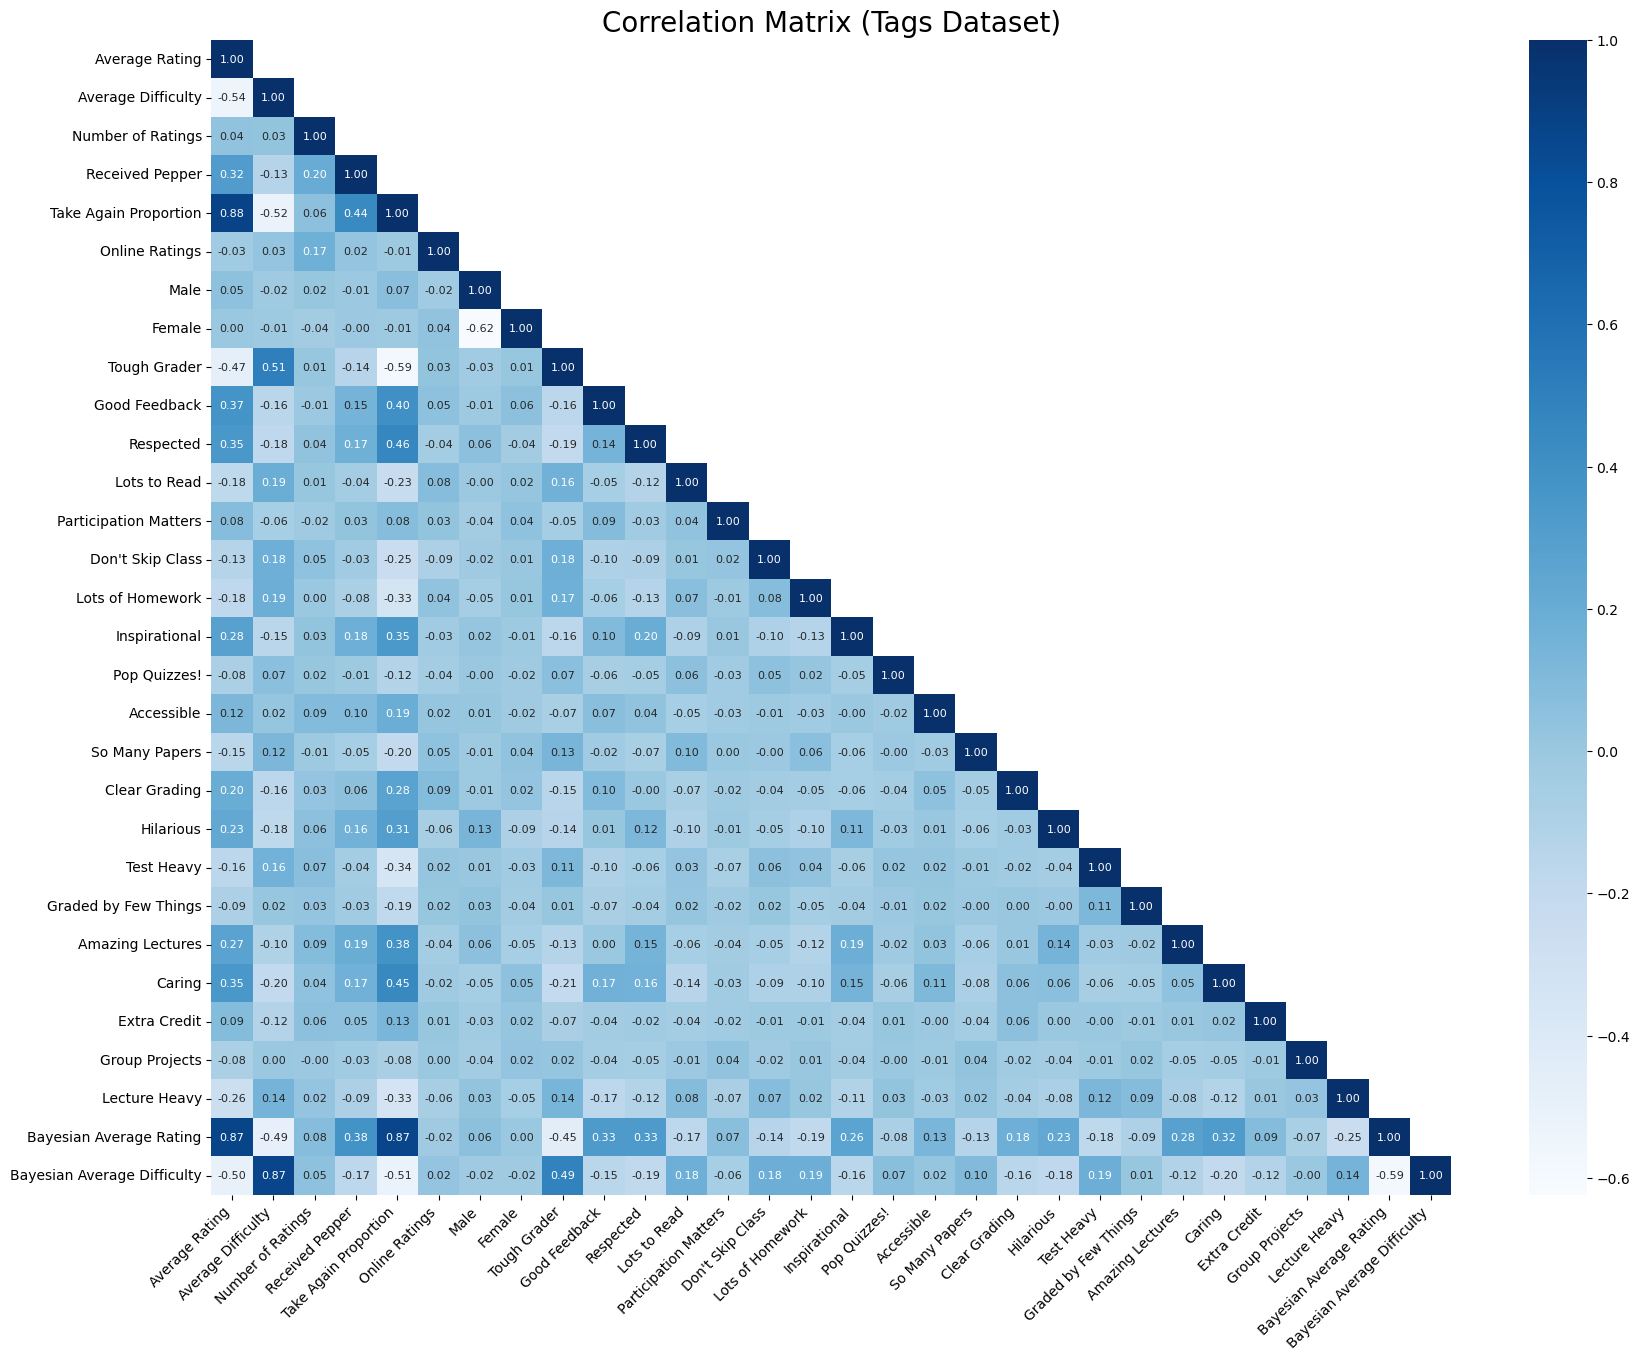

In [45]:
# Calculate the correlation matrix
correlation_matrix = merged_df.drop(columns= ["Major/Field", "University", "US State"]).corr()

# Generate a mask for the upper triangle without the diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

# Set the figure size
plt.figure(figsize=(20, 15))

# Create the heatmap with the mask
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cbar=True, cmap="Blues", annot_kws={'size': 8}, mask=mask)

# Add a title
plt.title('Correlation Matrix (Tags Dataset)', fontsize=20)

# Rotate x-axis and y-axis tick labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()

### Correlation ≥ 0.5

In [46]:
# Filter the correlations greater than or equal to 0.5
correlations = correlation_matrix.where(mask).stack().reset_index()

# Rename the columns
correlations.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Filter for correlations >= 0.5
strong_correlations = correlations[correlations['Correlation'] >= abs(0.5)]

strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
3,Average Rating,Take Again Proportion,0.880619
27,Average Rating,Bayesian Average Rating,0.874003
35,Average Difficulty,Tough Grader,0.509484
56,Average Difficulty,Bayesian Average Difficulty,0.870572
133,Take Again Proportion,Bayesian Average Rating,0.869236


# Question 1: Gender Bias in Professor Ratings

In [161]:
# Because data isn't normally distributed, we'll use the Mann-Whitney U test
# First we'll assume the test accounts for confounders

q1 = merged_df.copy()

# First, set a minimum threshold on the number of ratings to 3 where 3 is the median
q1 = q1[q1['Number of Ratings'] >= 3]

# Remove rows where male *and* female both == 1 or male *and* female both == 0
# That way, we include males *or* females

q1 = q1[~(((q1['Male'] == 1) & (q1['Female'] == 1)) | ((q1['Male'] == 0) & (q1['Female'] == 0)))]

# Create a new column in the q1 dataframe called "Male" (binary). This way, the comparison using the beta 
# coefficnets will be in reference to females (as opposed to non-binary)
q1['gender'] = np.where(q1['Male'] == 1, 1, 0)
# Lastly, drop rows with NaN values and drop 'Male' and 'Female' columns

q1 = q1.drop(columns=['Male', 'Female'])

# At this point only column with nan values is 'Take Again Proportion' column
q1 = q1.dropna(subset=['Take Again Proportion'])

# Perform significance test:
# A one-tailed Mann-Whitney U test was chosen because we're specifically testing students would rate male professors higher than female professors.
#This test is appropriate for ordinal data and does not require the assumption of normality, which aligns well with the nature of ratings data.

# Average ratings for female and male profesors
female_avg_rating = q1[q1['gender'] == 0]['Average Rating']
male_avg_rating = q1[q1['gender'] == 1]['Average Rating']

/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


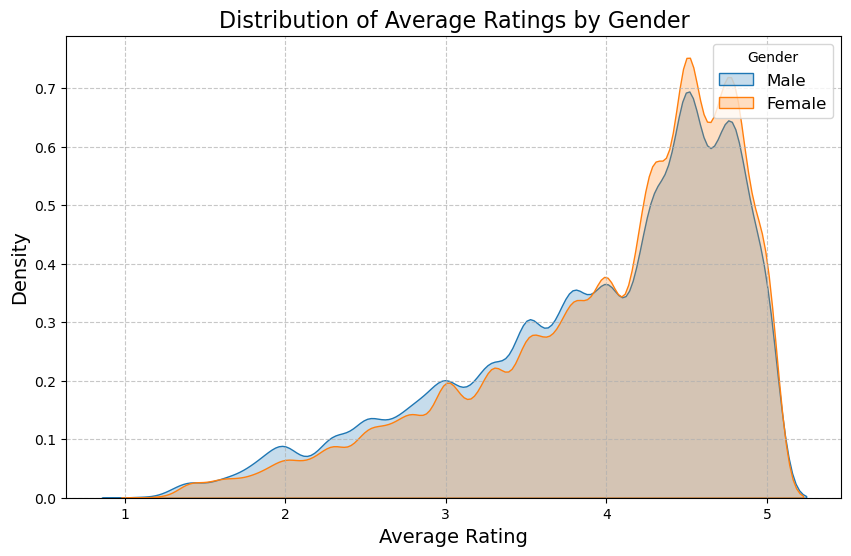

In [163]:
# Plot KDE for male and female ratings
plt.figure(figsize=(10, 6))
sns.kdeplot(female_avg_rating, label='Male', fill=True, bw_adjust=0.5)
sns.kdeplot(male_avg_rating, label='Female', fill=True, bw_adjust=0.5)

# Customize plot
plt.title('Distribution of Average Ratings by Gender', fontsize=16)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Gender', fontsize=12)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.show()

In [164]:
stat, p_value = mannwhitneyu(male_avg_rating, female_avg_rating, alternative='greater')

# Determine if there is a significant difference
print(f'Mann-Whitney U test statistic: {stat}')
print(f'p-value: {p_value}')

alpha = 0.005

if p_value < alpha:
    print("There is a significant difference in average ratings between male and female professors.")
else:
    print("There is no significant difference in average ratings male and female professors.")

Mann-Whitney U test statistic: 10149152.5
p-value: 4.2244749368356156e-05
There is a significant difference in average ratings between male and female professors.


In [165]:
# Split every feature by gender and check significance differences between two genders for that features 
results = {}
is_significant = 0

for col in q1.columns:
    if col != "gender" and pd.api.types.is_numeric_dtype(q1[col]):
        stat, p_value = mannwhitneyu( q1[q1['gender'] == 1][col], q1[q1['gender'] == 0][col], alternative='greater')
        is_significant = p_value < 0.005 
        if (is_significant == 1):
            results[col] = {'p-value': p_value, 'significant': is_significant}

        
# Print the results
for col, result in results.items():
    
    print(f"Column: {col}, P-value: {result['p-value']}, Significant: {result['significant']}")


Column: Average Rating, P-value: 4.2244749368356156e-05, Significant: True
Column: Number of Ratings, P-value: 9.091761003107938e-06, Significant: True
Column: Take Again Proportion, P-value: 2.212042235178904e-06, Significant: True
Column: Respected, P-value: 7.127138899739437e-21, Significant: True
Column: Inspirational, P-value: 1.723090887032305e-05, Significant: True
Column: Accessible, P-value: 0.000817328268562894, Significant: True
Column: Hilarious, P-value: 3.225352399044042e-109, Significant: True
Column: Test Heavy, P-value: 3.147194753180452e-06, Significant: True
Column: Graded by Few Things, P-value: 8.06340217176686e-15, Significant: True
Column: Amazing Lectures, P-value: 1.0382844658726876e-24, Significant: True
Column: Lecture Heavy, P-value: 1.1151417751015201e-10, Significant: True
Column: Bayesian Average Rating, P-value: 8.412171279225942e-06, Significant: True


In [166]:
results.pop('Bayesian Average Rating', None)
results.pop('Bayesian Average Difficulty', None)
results

{'Average Rating': {'p-value': 4.2244749368356156e-05, 'significant': True},
 'Number of Ratings': {'p-value': 9.091761003107938e-06, 'significant': True},
 'Take Again Proportion': {'p-value': 2.212042235178904e-06,
  'significant': True},
 'Respected': {'p-value': 7.127138899739437e-21, 'significant': True},
 'Inspirational': {'p-value': 1.723090887032305e-05, 'significant': True},
 'Accessible': {'p-value': 0.000817328268562894, 'significant': True},
 'Hilarious': {'p-value': 3.225352399044042e-109, 'significant': True},
 'Test Heavy': {'p-value': 3.147194753180452e-06, 'significant': True},
 'Graded by Few Things': {'p-value': 8.06340217176686e-15,
  'significant': True},
 'Amazing Lectures': {'p-value': 1.0382844658726876e-24, 'significant': True},
 'Lecture Heavy': {'p-value': 1.1151417751015201e-10, 'significant': True}}

In [167]:
# split every feature that showed significane when split by gender by average rating to make sure that that feature is also significant against average rating hence a confounder
comparison_results = {}

for feature in results:
    if feature not in ['gender', 'Average Rating', 'Bayesian Average Rating', 'Bayesian Average Difficulty'] and pd.api.types.is_numeric_dtype(q1[feature]):
        
        # Define a threshold for the feature (e.g., median split)
        threshold = q1[feature].median()
        
        # Split Average Rating based on the feature
        low_group = q1[q1[feature] <= threshold]['Average Rating']
        high_group = q1[q1[feature] > threshold]['Average Rating']
        
        # Perform the Mann-Whitney U test
        stat, p_value = mannwhitneyu(high_group,low_group, alternative='greater')
        
        # Check for significance
        is_significant = p_value < 0.005
        if is_significant:
            comparison_results[feature] = {'p-value': p_value, 'significant': is_significant}

# Display results
for feature, result in comparison_results.items():
    print(f"Feature: {feature}, P-value: {result['p-value']}, Significant: {result['significant']}")

print(f"Number of significant features: {len(comparison_results)}")

Feature: Take Again Proportion, P-value: 0.0, Significant: True
Feature: Respected, P-value: 0.0, Significant: True
Feature: Inspirational, P-value: 0.0, Significant: True
Feature: Accessible, P-value: 1.185557807100607e-28, Significant: True
Feature: Hilarious, P-value: 3.121586106550883e-214, Significant: True
Feature: Amazing Lectures, P-value: 0.0, Significant: True
Number of significant features: 6


# Question 2: Gender Difference on the Spread

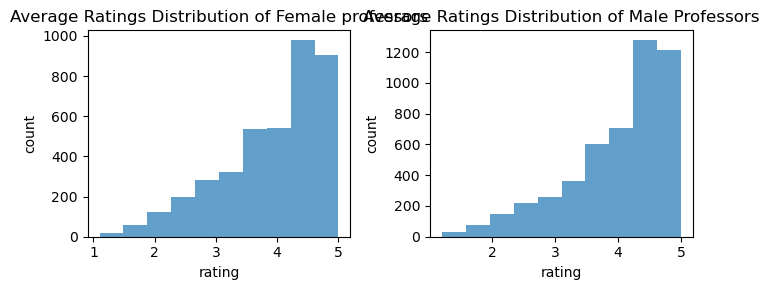

In [168]:
# Visualize our two distributions 
fig,ax = plt.subplots(ncols=2,figsize=(7,3))
ax[0].hist(female_avg_rating,bins=10,alpha=0.7)
ax[0].set_xlabel("rating")
ax[0].set_ylabel("count")
ax[0].set_title("Average Ratings Distribution of Female professors")

ax[1].hist(male_avg_rating,bins=10,alpha=0.7)
ax[1].set_xlabel("rating")
ax[1].set_ylabel("count")
ax[1].set_title("Average Ratings Distribution of Male Professors")
plt.tight_layout()



In [171]:
# Significance Test: Using Levene Test for spread/dispersion
# Levene's test is used to test the null hypothesis that all input samples are from populations with equal variances.
# Perform the Levene test
stat, p_value = levene(female_avg_rating, male_avg_rating)

print("Levene's test statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.005:
    print("The variances are significantly different.")
else:
    print("The variances are not significantly different.")


Levene's test statistic: 12.800894038962834
p-value: 0.0003483061439696078
The variances are significantly different.


In [173]:
# Significance Test: Use Permutation Test for spread/dispersion

# combine data from both dists into one array
combined_ratings = np.append(female_avg_rating.values, male_avg_rating.values)
n_female = len(female_avg_rating)  
n_male = len(male_avg_rating)  

#P Define test statistic 
#we need to define a test statistic that we expect to be large if the two distributions are different, and small if they are similar
#lets say for this example that our test statistic will be the difference in variance of our distributions
def test_stat(d1, d2):
    return np.var(d1, ddof=1) - np.var(d2, ddof=1)


# Initialize number of permutations we want to compute and results list 
null_dist = []
n_exp = 10000 


permuted = np.random.permutation(combined_ratings)
p1 = permuted[:n_female]
p2 = permuted[n_female:]

# Compute the test statistic for each permutation
for i in range(n_exp):
    np.random.shuffle(combined_ratings)
    
    p1 = combined_ratings[:n_female]
    p2 = combined_ratings[n_female:]
    
    #compute test statistic 
    stat = test_stat(p1,p2)
    
    #save result
    null_dist.append(stat)
    
#Compute the test statistic for our true distribution 
statistic = test_stat(female_avg_rating.values, male_avg_rating.values)

#Compute the p-value and visualize our results
#we can compute the pvalue by determining the area of the null distribution that lies within our alternative hypothesis 
#so, if our alternate hypothesis is "greater", we want to determine the area of the null distribution that is larger than our test statistic
pvalue = sum(np.abs(null_dist) >= np.abs(statistic)) / n_exp


print(f"Observed difference in variance: {statistic}")
print(f"P-value: {pvalue}")

if pvalue < 0.005:
    print("There is a significant difference in the variance of ratings between genders.")
else:
    print("There is no significant difference in the variance of ratings between genders.")

Observed difference in variance: 0.05985239055860314
P-value: 0.0066
There is no significant difference in the variance of ratings between genders.


# Question 3: Effects of Gender Bias of Average Rating and the Spread of Average Rating

#### Effects of gender bias in average rating

In [174]:
def cohens_d(group1, group2):
    # Compute the means and standard deviations for the two groups
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    # Pooled standard deviation
    pooled_std = np.sqrt(((len(group1) - 1) * std1**2 + (len(group2) - 1) * std2**2) / 
                         (len(group1) + len(group2) - 2))
    return (mean1 - mean2) / pooled_std

def bootstrap_cohens_d(group1, group2, num_bootstraps=10000, random_seed=seed):
    rng = np.random.default_rng(random_seed)
    boot_d_values = []
    # Perform bootstrapping
    for i in range(num_bootstraps):
        # Resample with replacement
        sample1 = rng.choice(group1, size=len(group1), replace=True)
        sample2 = rng.choice(group2, size=len(group2), replace=True)
        # Compute Cohen's d for the resampled data
        boot_d_values.append(cohens_d(sample1, sample2))
    
    # Calculate 95% confidence interval
    lower_bound = np.percentile(boot_d_values, 2.5)
    upper_bound = np.percentile(boot_d_values, 97.5)
    
    return np.array(boot_d_values), lower_bound, upper_bound

In [175]:
# Cohen's d and 95% CI

cohen_d_value = cohens_d(male_avg_rating, female_avg_rating)
boot_d_values, d_lower, d_upper = bootstrap_cohens_d(male_avg_rating, female_avg_rating)
print(f"Cohen's d: {cohen_d_value}")
print(f"95% CI for Cohen's d: ({d_lower}, {d_upper})")

Cohen's d: 0.0900276992182447
95% CI for Cohen's d: (0.047212574264772905, 0.13208603302452282)


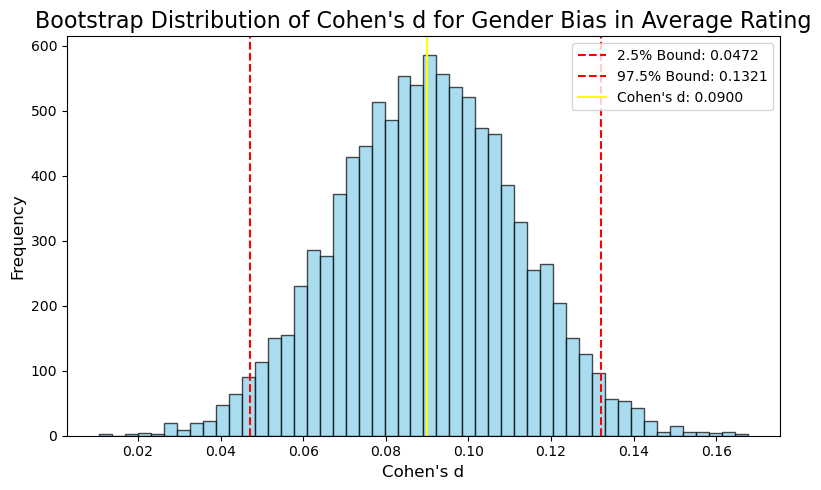

In [176]:
# Plot the bootstrap distribution of Cohen's d
plt.figure(figsize=(8, 5))
plt.hist(boot_d_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(d_lower, color='red', linestyle='dashed', linewidth=1.5, label=f'2.5% Bound: {d_lower:.4f}')
plt.axvline(d_upper, color='red', linestyle='dashed', linewidth=1.5, label=f'97.5% Bound: {d_upper:.4f}')
plt.axvline(cohen_d_value, color='yellow', linestyle='solid', linewidth=1.5, label=f'Cohen\'s d: {cohen_d_value:.4f}')
plt.title("Bootstrap Distribution of Cohen's d for Gender Bias in Average Rating", fontsize=16)
plt.xlabel("Cohen's d", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### Effects of gender bias in spread of average rating

In [177]:
def variance_effect_size(group1, group2):
    # Compute the variances for the two groups
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)

    # Compute pooled variance
    pooled_std = np.sqrt(((len(group1) - 1) * std1**2 + (len(group2) - 1) * std2**2) / 
                         (len(group1) + len(group2) - 2))    
    # Effect size for variance differences
    return (var1 - var2) / pooled_std

def bootstrap_variance_effect_size(group1, group2, num_bootstraps=10000, random_seed=seed):
    rng = np.random.default_rng(random_seed)
    boot_var_effect_sizes = []
    
    # Perform bootstrapping
    for i in range(num_bootstraps):
        # Resample with replacement
        sample1 = rng.choice(group1, size=len(group1), replace=True)
        sample2 = rng.choice(group2, size=len(group2), replace=True)
        
        # Compute effect size for variance differences
        boot_var_effect_sizes.append(variance_effect_size(sample1, sample2))
    
    # Calculate 95% confidence interval
    lower_bound = np.percentile(boot_var_effect_sizes, 2.5)
    upper_bound = np.percentile(boot_var_effect_sizes, 97.5)
    
    return np.array(boot_var_effect_sizes), lower_bound, upper_bound


In [178]:
effect_size_variance = variance_effect_size(male_avg_rating, female_avg_rating)
boot_v_values, d_lower, d_upper = bootstrap_variance_effect_size(male_avg_rating, female_avg_rating)
print(f"variance effect size {effect_size_variance}")
print(f"95% CI for variance effect size: ({d_lower}, {d_upper})")

variance effect size -0.07191639398209428
95% CI for variance effect size: (-0.12350704440160938, -0.020651533029565725)


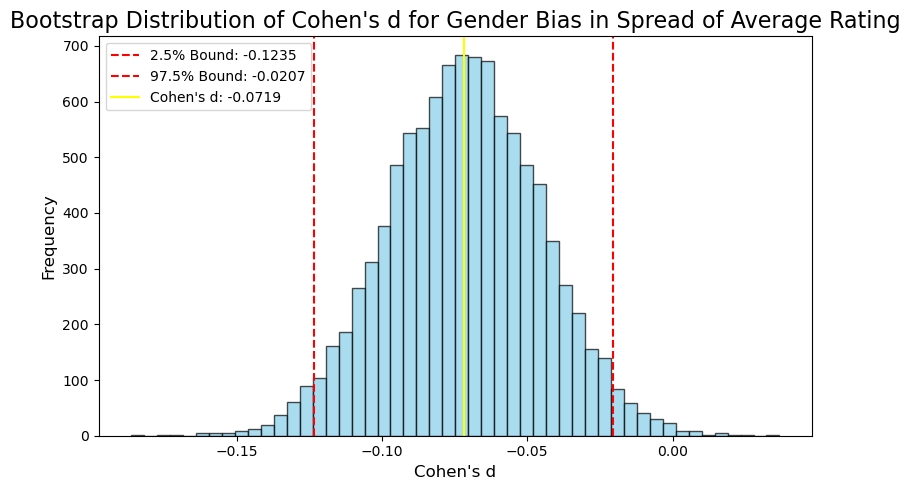

In [179]:
# Plot the bootstrap distribution of Cohen's d
plt.figure(figsize=(8, 5))
plt.hist(boot_v_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(d_lower, color='red', linestyle='dashed', linewidth=1.5, label=f'2.5% Bound: {d_lower:.4f}')
plt.axvline(d_upper, color='red', linestyle='dashed', linewidth=1.5, label=f'97.5% Bound: {d_upper:.4f}')
plt.axvline(effect_size_variance, color='yellow', linestyle='solid', linewidth=1.5, label=f'Cohen\'s d: {effect_size_variance:.4f}')
plt.title("Bootstrap Distribution of Cohen's d for Gender Bias in Spread of Average Rating", fontsize=16)
plt.xlabel("Cohen's d", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Question 4: Gender Difference
**Goal:** Is there a gender difference in the tags awarded by students? Make sure to teach each of the 20 tags for a potential gender difference and report which of them exhibit a statistically significant different. Comment on the 3 most gendered (lowest p-value) and least gendered (highest p-value) tags. 

In [187]:
# Calculate the median of "Number of Ratings"
median_ratings = merged_df["Number of Ratings"].median()

# Filter the dataset to exclude entries with "Number of Ratings" below the median
filtered_df = merged_df[merged_df["Number of Ratings"] >= median_ratings]

In [188]:
tags.columns

Index(['Tough Grader', 'Good Feedback', 'Respected', 'Lots to Read',
       'Participation Matters', 'Don't Skip Class', 'Lots of Homework',
       'Inspirational', 'Pop Quizzes!', 'Accessible', 'So Many Papers',
       'Clear Grading', 'Hilarious', 'Test Heavy', 'Graded by Few Things',
       'Amazing Lectures', 'Caring', 'Extra Credit', 'Group Projects',
       'Lecture Heavy'],
      dtype='object')

In [189]:
# Extract data for tags and genders
tags = filtered_df[['Tough Grader', 'Good Feedback', 'Respected', 'Lots to Read',
       'Participation Matters', "Don't Skip Class", 'Lots of Homework',
       'Inspirational', 'Pop Quizzes!', 'Accessible', 'So Many Papers',
       'Clear Grading', 'Hilarious', 'Test Heavy', 'Graded by Few Things',
       'Amazing Lectures', 'Caring', 'Extra Credit', 'Group Projects',
       'Lecture Heavy']] 
genders = filtered_df[['Male', 'Female']]

/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

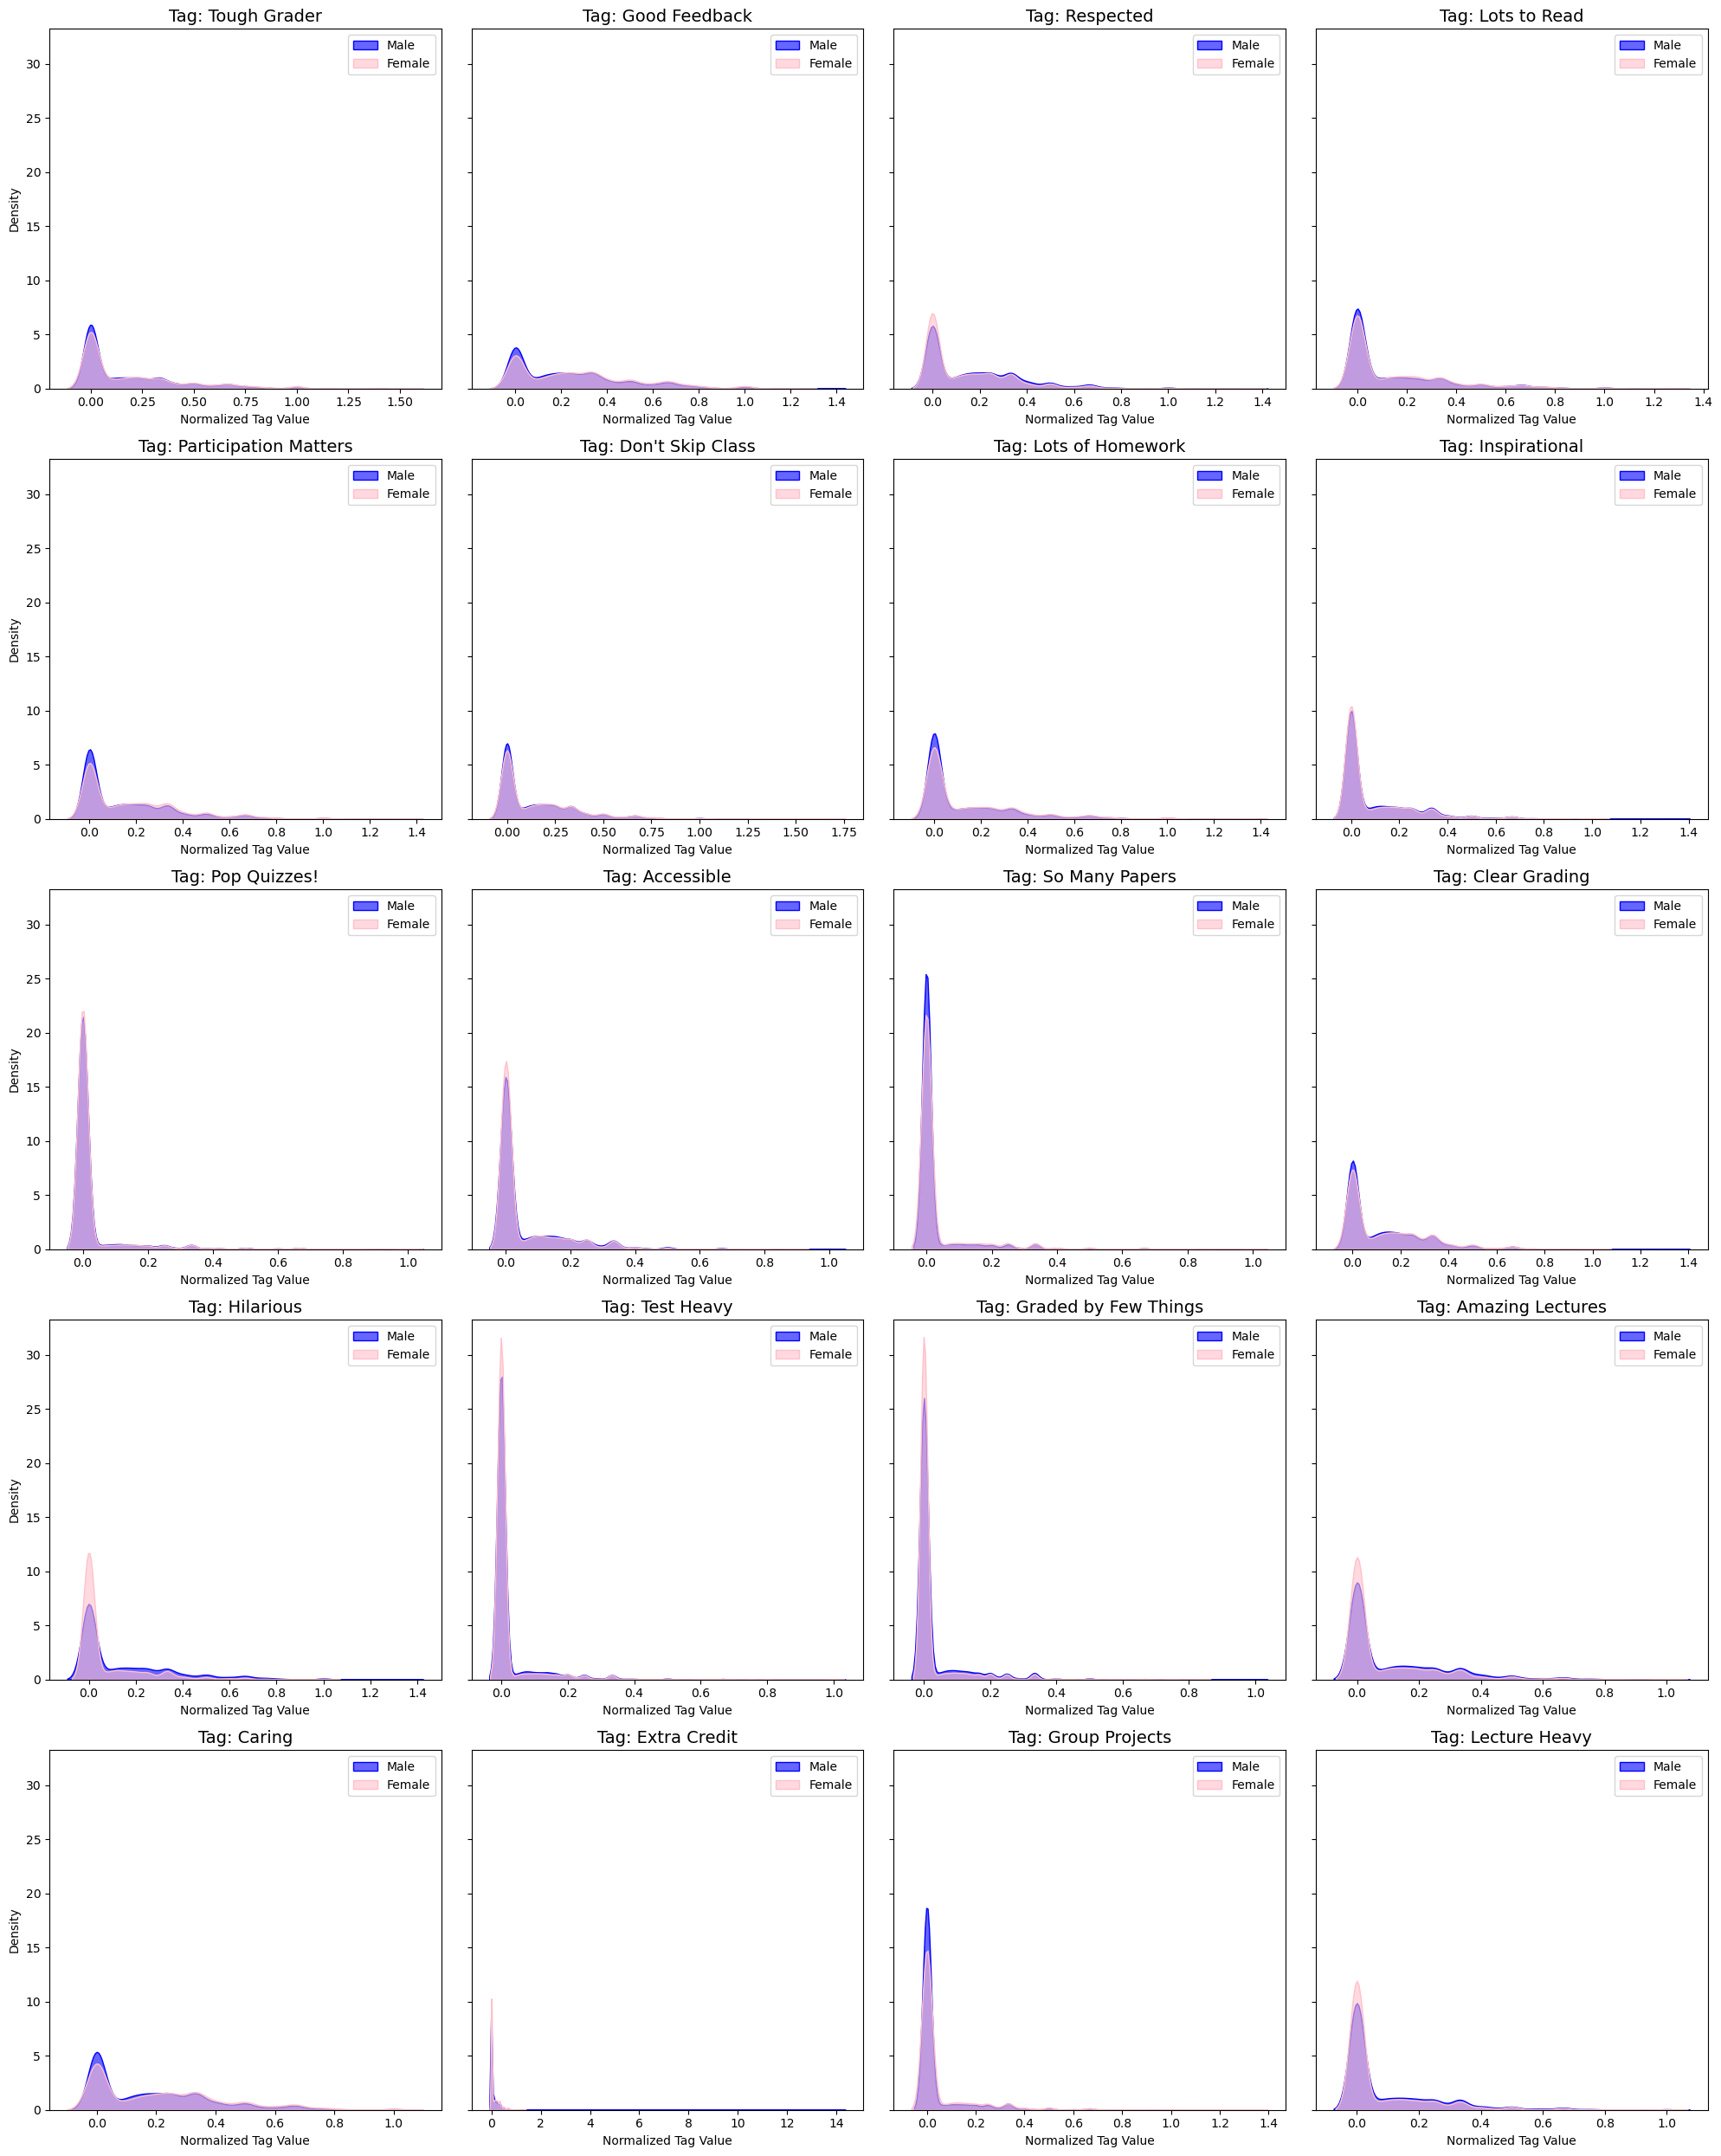

In [190]:
num_tags = tags.shape[1] # Number of tags
num_cols = 4  # Number of columns in the grid
num_rows = math.ceil(num_tags / num_cols)  # Calculate rows needed

# Create the subplot grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5), sharey=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot distributions for each tag
for i, tag in enumerate(tags.columns):
    ax = axes[i]
    # Male distribution
    sns.kdeplot(
        data=filtered_df[filtered_df['Male'] == 1][tag].dropna(), 
        label='Male', fill=True, color='blue', alpha=0.6, ax=ax
    )
    # Female distribution
    sns.kdeplot(
        data=filtered_df[filtered_df['Female'] == 1][tag].dropna(), 
        label='Female', fill=True, color='pink', alpha=0.6, ax=ax
    )
    # Titles and labels
    ax.set_title(f'Tag: {tag}', fontsize=14)
    ax.set_xlabel('Normalized Tag Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

It appears that the distributions for many of the tags are not normally distributed. The following observations make a strong case for using the Mann-Whitney U test instead of a t-test. 

- Most tags exhibit a high concentration of values near 0, with long tails extending to the right. This indicates skewness, violating the normality assumption required for a t-test.
- The spread of the distributions for males and females appears unequal for certain tags, which further suggests that a t-test may not be appropriate.
- Since the tags are normalized but still represent discrete counts (e.g., the number of times a tag was assigned), their underlying distribution may inherently differ from a continuous normal distribution.

In [191]:
# Initialize a list to store results
results = []

# Perform Mann-Whitney U test for each tag
for tag in tags.columns:
    male_values = filtered_df[filtered_df['Male'] == 1][tag].dropna()
    female_values = filtered_df[filtered_df['Female'] == 1][tag].dropna()
    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(male_values, female_values, alternative='two-sided')
    # Determine significance based on p-value
    significant = p_value < 0.005
    # Append results to the list
    results.append({'Tag': tag, 'U-Statistic': stat, 'P-Value': p_value, 'Significant': significant})

# Convert results to a DataFrame
results_df = pd.DataFrame(results)
# Sort the entire DataFrame by P-Value in ascending order
results_df = results_df.sort_values(by='P-Value', ascending=True)

In [192]:
print("---------------Results of Mann-Whitney U Tests for All Tags:---------------")
print(results_df)

---------------Results of Mann-Whitney U Tests for All Tags:---------------
                      Tag  U-Statistic        P-Value  Significant
12              Hilarious  130823899.5  3.707160e-228         True
15       Amazing Lectures  120034116.0   5.506070e-54         True
19          Lecture Heavy  118242699.0   3.049018e-39         True
16                 Caring  100751939.5   1.422116e-37         True
2               Respected  118619220.0   5.018935e-35         True
4   Participation Matters  101350254.0   3.865224e-34         True
1           Good Feedback  101236459.0   4.001436e-33         True
14   Graded by Few Things  115480384.0   2.801610e-31         True
18         Group Projects  104731292.5   1.651462e-24         True
6        Lots of Homework  104262502.5   2.958607e-17         True
10         So Many Papers  106446050.5   1.459034e-14         True
17           Extra Credit  105246648.5   1.560893e-14         True
13             Test Heavy  113102672.0   3.183859e-12

In [193]:
# Display significant and non-significant tags
significant_tags = results_df[results_df['Significant'] == True]
non_significant_tags = results_df[results_df['Significant'] == False]
print("\n----------Top 3 Most Significant Tags (P-Value < 0.005):----------")
print(significant_tags.head(3))
print("\n----------Top 3 Most Non-Significant Tags (P-Value >= 0.005):----------")
print(non_significant_tags.head(3))


----------Top 3 Most Significant Tags (P-Value < 0.005):----------
                 Tag  U-Statistic        P-Value  Significant
12         Hilarious  130823899.5  3.707160e-228         True
15  Amazing Lectures  120034116.0   5.506070e-54         True
19     Lecture Heavy  118242699.0   3.049018e-39         True

----------Top 3 Most Non-Significant Tags (P-Value >= 0.005):----------
            Tag  U-Statistic   P-Value  Significant
8  Pop Quizzes!  110916313.0  0.026565        False


# Question 5: Significance Test
**Goal:**  Is there a gender difference in terms of average difficulty? Again, a significance test is indicated. 

In [54]:
# Calculate the median of "Number of Ratings"
median_ratings = merged_df["Number of Ratings"].median()

# Filter the dataset to exclude entries with "Number of Ratings" below the median
filtered_df = merged_df[merged_df["Number of Ratings"] >= median_ratings]

In [55]:
# Seperate the data by gender for the 'Average Rating' column
male_difficulty = filtered_df[filtered_df['Male'] == 1]['Bayesian Average Difficulty']
female_difficulty = filtered_df[filtered_df['Female'] == 1]['Bayesian Average Difficulty']

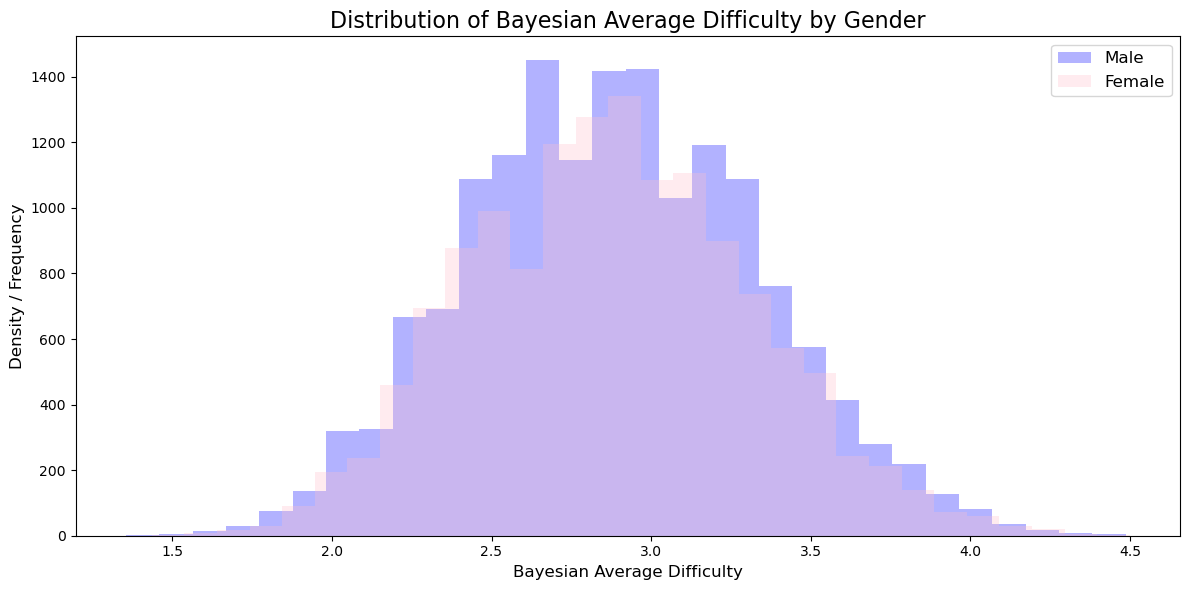

In [56]:
# Visualize the distributions to identify which significance test to use
plt.figure(figsize=(12, 6))
# Add histogram overlay for a clearer distribution view
plt.hist(male_difficulty, bins=30, alpha=0.3, color="blue", label="Male")
plt.hist(female_difficulty, bins=30, alpha=0.3, color="pink", label="Female")
# Add title and labels
plt.title("Distribution of Bayesian Average Difficulty by Gender", fontsize=16)
plt.xlabel("Bayesian Average Difficulty", fontsize=12)
plt.ylabel("Density / Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

The distributions of the “Bayesian Average Difficulty” ratings for male and female professors appear to be normally distributed, as seen from the visualization above. This suggests that the assumption of normality for a t-test holds, hence implementing an independent samples t-test to answer this question is most appropriate.

In [57]:
# Independent t-test 
t_stat, p_value = ttest_ind(male_difficulty.dropna(), female_difficulty.dropna())
print("Independent samples t-test Results:")
print(f"t-test statistic: {t_stat}, p-value: {p_value:.4f}")

if p_value < 0.005:
    print("There is a statistically significant difference in average difficulty between male and female professors.")
else:
    print("No statistically significant difference in average difficulty between male and female professors.")

Independent samples t-test Results:
t-test statistic: 0.2929742499370975, p-value: 0.7695
No statistically significant difference in average difficulty between male and female professors.


# Question 6: Effect Size
**Goal:** Please quantify the likely size of this effect at 95% confidence.

In [58]:
# Function to compute Cohen's d
def cohens_d(group1, group2):
    # Compute the means and standard deviations for the two groups
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    # Pooled standard deviation
    pooled_std = np.sqrt(((len(group1) - 1) * std1**2 + (len(group2) - 1) * std2**2) / 
                         (len(group1) + len(group2) - 2))
    return (mean1 - mean2) / pooled_std

In [59]:
# Function to bootstrap Cohen's d
def bootstrap_cohens_d(group1, group2, num_bootstraps=10000, random_seed=seed):
    rng = np.random.default_rng(random_seed)
    boot_d_values = []
    # Perform bootstrapping
    for i in range(num_bootstraps):
        # Resample with replacement
        sample1 = rng.choice(group1, size=len(group1), replace=True)
        sample2 = rng.choice(group2, size=len(group2), replace=True)
        # Compute Cohen's d for the resampled data
        boot_d_values.append(cohens_d(sample1, sample2))
    
    # Calculate 95% confidence interval
    lower_bound = np.percentile(boot_d_values, 2.5)
    upper_bound = np.percentile(boot_d_values, 97.5)
    
    return np.array(boot_d_values), lower_bound, upper_bound

In [60]:
# Extract data
male_difficulty = filtered_df[filtered_df['Male'] == 1]['Bayesian Average Difficulty'].dropna().to_numpy()
female_difficulty = filtered_df[filtered_df['Female'] == 1]['Bayesian Average Difficulty'].dropna().to_numpy()
# Compute Cohen's d
d = cohens_d(male_difficulty, female_difficulty)
print(f"Cohen's d: {d:.4f}")

Cohen's d: 0.0034


In [61]:
 # Bootstrap Cohen's d for confidence intervals
boot_d_values, lower_ci, upper_ci = bootstrap_cohens_d(male_difficulty, female_difficulty)
print(f"95% Confidence Interval for Cohen's d: ({lower_ci:.4f}, {upper_ci:.4f})")

95% Confidence Interval for Cohen's d: (-0.0191, 0.0263)


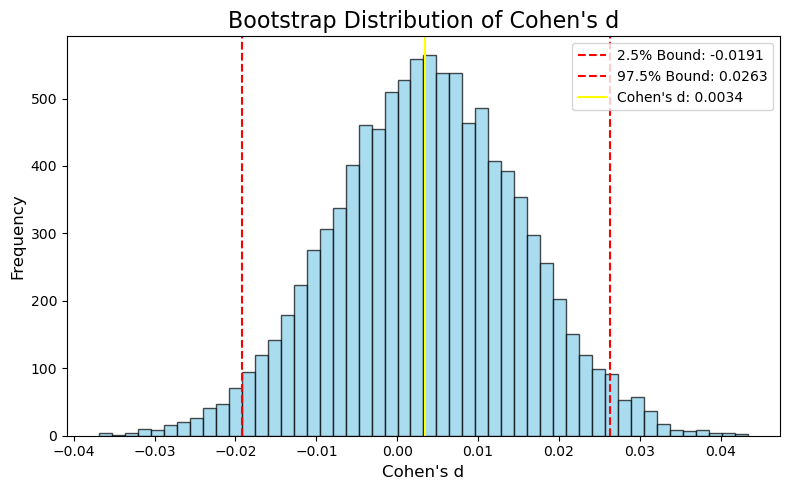

In [62]:
# Plot the bootstrap distribution of Cohen's d
plt.figure(figsize=(8, 5))
plt.hist(boot_d_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(lower_ci, color='red', linestyle='dashed', linewidth=1.5, label=f'2.5% Bound: {lower_ci:.4f}')
plt.axvline(upper_ci, color='red', linestyle='dashed', linewidth=1.5, label=f'97.5% Bound: {upper_ci:.4f}')
plt.axvline(d, color='yellow', linestyle='solid', linewidth=1.5, label=f'Cohen\'s d: {d:.4f}')
plt.title("Bootstrap Distribution of Cohen's d", fontsize=16)
plt.xlabel("Cohen's d", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Question 7: Regression
**Goal:** Build a regression model to predict average rating from all numerical predictors (the ones in the 
rmpCapstoneNum.csv)

In [63]:
merged_df["Take Again Proportion"].isnull().sum()

55871

#### Appraoch (a): Drop the 55871 missing values in the Take Again Proportion column

In [64]:
# Define the outcome variable (target) and predictors
# Drop the outcome variable and irrelevant columns to isolate predictors

q7 = merged_df.copy().dropna()

X = q7[["Bayesian Average Difficulty", "Number of Ratings",
        "Received Pepper", "Take Again Proportion", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

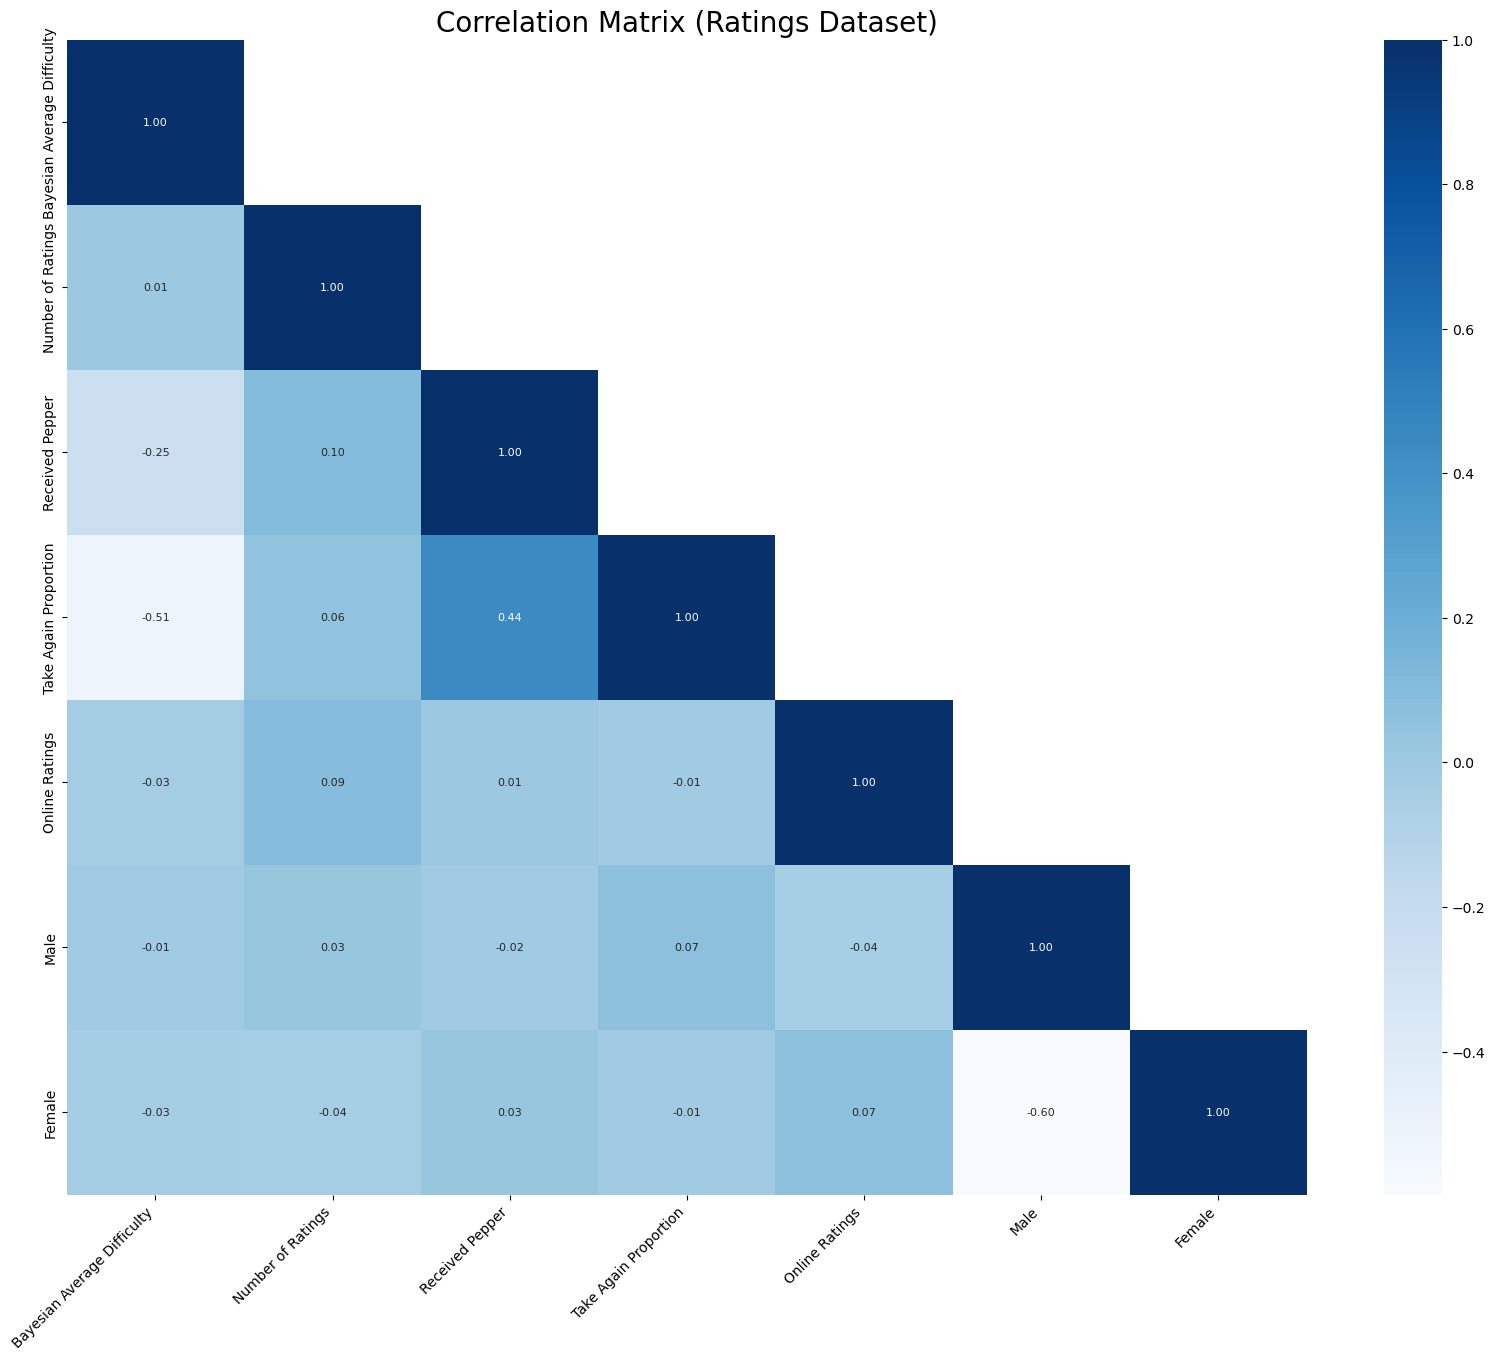

In [65]:
# Calculate the correlation matrix
correlation_matrix = X.corr()

# Generate a mask for the upper triangle without the diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

# Set the figure size
plt.figure(figsize=(20, 15))

# Create the heatmap with the mask
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cbar=True, cmap="Blues", annot_kws={'size': 8}, mask=mask)

# Add a title
plt.title('Correlation Matrix (Ratings Dataset)', fontsize=20)

# Rotate x-axis and y-axis tick labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()

In [66]:
# Filter the correlations greater than or equal to 0.5
correlations = correlation_matrix.where(mask).stack().reset_index()

# Rename the columns
correlations.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Filter for correlations >= 0.5 or <= -0.5
strong_correlations = correlations[
    (correlations['Correlation'] >= 0.4) | (correlations['Correlation'] <= -0.4)
]

strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
2,Bayesian Average Difficulty,Take Again Proportion,-0.513612
11,Received Pepper,Take Again Proportion,0.441665
20,Male,Female,-0.598265


In [67]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Add a column for the absolute value of the coefficients
df_coefficients['Absolute Coefficient'] = df_coefficients['Coefficient'].abs()

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)
df_coefficients['Absolute Coefficient'] = df_coefficients['Absolute Coefficient'].round(2)

# Sort the DataFrame by the absolute value of the coefficients
df_coefficients_sorted = df_coefficients.sort_values(by='Absolute Coefficient', ascending=False)

# Display the sorted DataFrame
df_coefficients_sorted

,Variable,Coefficient,Absolute Coefficient
0,Intercept,2.76,2.76
1,Bayesian Average Difficulty,-0.29,0.29
3,Received Pepper,0.20,0.20
6,Male,0.06,0.06
7,Female,0.03,0.03
4,Take Again Proportion,0.02,0.02
2,Number of Ratings,-0.00,0.00
5,Online Ratings,0.00,0.00


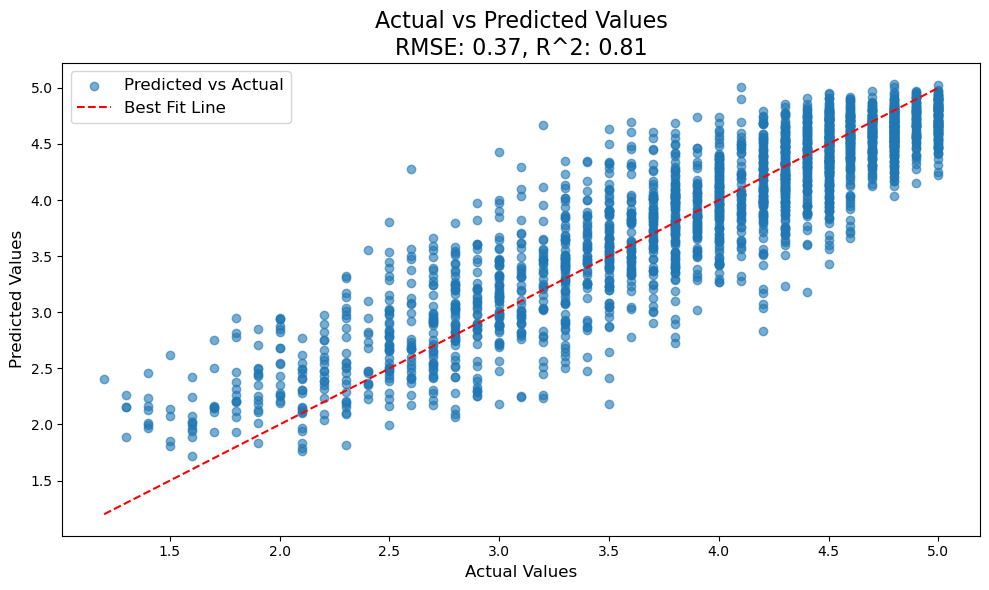

In [68]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Approach (b): Impute the 57844 missing values in the Take Again Proportion column with the mean

In [69]:
# Create a copy of the dataset to avoid overwriting the original
q7 = merged_df.copy()

# Impute missing values in 'Take Again Proportion' with the mean
q7["Take Again Proportion"].fillna(q7["Take Again Proportion"].mean(), inplace=True)

# Define the outcome variable (target) and predictors
X = q7[["Bayesian Average Difficulty", "Number of Ratings",
        "Received Pepper", "Take Again Proportion", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

/var/folders/ss/0b8pnhm92wggrcpr3x3jsstc0000gn/T/ipykernel_67021/3351775378.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  q7["Take Again Proportion"].fillna(q7["Take Again Proportion"].mean(), inplace=True)


In [70]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)

# Display the DataFrame
df_coefficients.sort_values(by = "Coefficient", ascending = False)

,Variable,Coefficient
0,Intercept,6.44
3,Received Pepper,0.55
6,Male,0.15
7,Female,0.09
4,Take Again Proportion,0.01
2,Number of Ratings,0.00
5,Online Ratings,-0.03
1,Bayesian Average Difficulty,-1.29


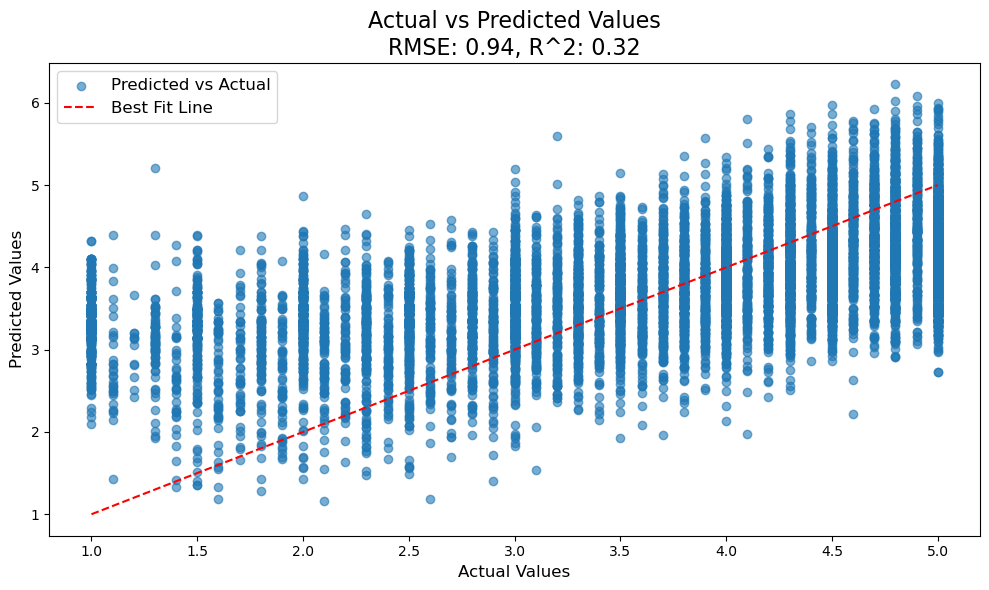

In [71]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Approach (c): Drop the `Take Again Proportion` Column

In [72]:
# Create a copy of the dataset to avoid overwriting the original
q7 = merged_df.copy()

# Define the outcome variable (target) and predictors
X = q7[["Bayesian Average Difficulty", "Number of Ratings",
        "Received Pepper", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [73]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)

# Display the DataFrame
df_coefficients.sort_values(by = "Coefficient", ascending = False)

,Variable,Coefficient
0,Intercept,7.48
3,Received Pepper,0.60
5,Male,0.16
6,Female,0.11
2,Number of Ratings,0.00
4,Online Ratings,-0.03
1,Bayesian Average Difficulty,-1.37


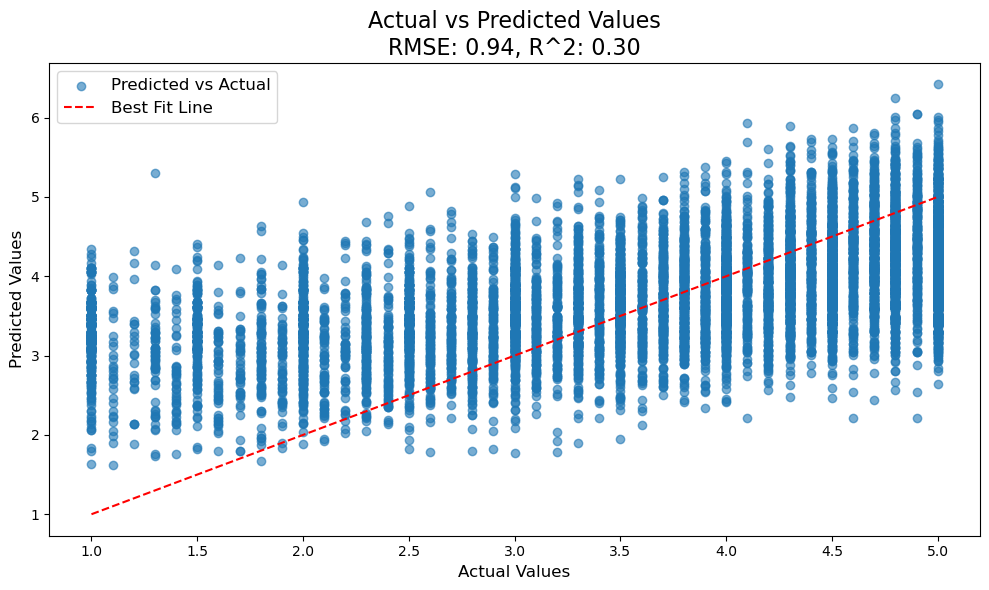

In [74]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Approach (d): Lasso (Feature Selection)
Out of (1) dropping the null values in `Take Again Proportion`, (2) imputing the null values, and (3) dropping the feature, dropping the null values resulted in the best evaluation metrics. Therefore, we are doing LASSO regression with dropping the null values.

In [75]:
# Create a copy of the dataset to avoid overwriting the original
q7 = merged_df.copy().dropna()

# Define the outcome variable (target) and predictors
X = q7[["Bayesian Average Difficulty", "Number of Ratings",
        "Received Pepper", "Take Again Proportion", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Standardizing the features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardizing the outcome variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Defining a range of alphas for Lasso
alphas = np.logspace(-6, 6, 1500)

# Initialize and fit LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=seed)
lasso_cv.fit(X_train_scaled, y_train_scaled)

# Find the optimal alpha
optimal_alpha_lasso = lasso_cv.alpha_

# Train the Lasso model with the optimal alpha
lasso = Lasso(alpha=optimal_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train_scaled)
y_pred_lasso_scaled = lasso.predict(X_test_scaled)

# Evaluate the Lasso model
r2_lasso_scaled = r2_score(y_test_scaled, y_pred_lasso_scaled)
rmse_lasso_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_lasso_scaled))

# Count the number of coefficients shrunk to zero
num_zero_coefs = np.sum(lasso.coef_ == 0)

# Print results
print(f"Optimal alpha (lambda) for Lasso: {round(optimal_alpha_lasso, 4)}")
print(f"R-squared for Lasso model (scaled outcome): {round(r2_lasso_scaled, 4)}")
print(f"RMSE for Lasso model (scaled outcome): {round(rmse_lasso_scaled, 4)}")
print(f"Number of predictors shrunk to zero: {num_zero_coefs}")

Optimal alpha (lambda) for Lasso: 0.0007
R-squared for Lasso model (scaled outcome): 0.8014
RMSE for Lasso model (scaled outcome): 0.4336
Number of predictors shrunk to zero: 0


In [76]:
# Create a DataFrame of feature names and their corresponding Lasso coefficients
coefficients_lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_
})

# Sort the DataFrame by the absolute values of the coefficients
coefficients_lasso_df['Absolute Coefficient'] = coefficients_lasso_df['Lasso Coefficient'].abs()
coefficients_lasso_df.sort_values(by="Absolute Coefficient", ascending=False, inplace=True)
coefficients_lasso_df.drop(columns=["Absolute Coefficient"], inplace=True)

# Display the DataFrame
coefficients_lasso_df

,Feature,Lasso Coefficient
3,Take Again Proportion,0.739804
0,Bayesian Average Difficulty,-0.170024
2,Received Pepper,0.118495
5,Male,0.031552
6,Female,0.022541
4,Online Ratings,-0.001545
1,Number of Ratings,0.000048


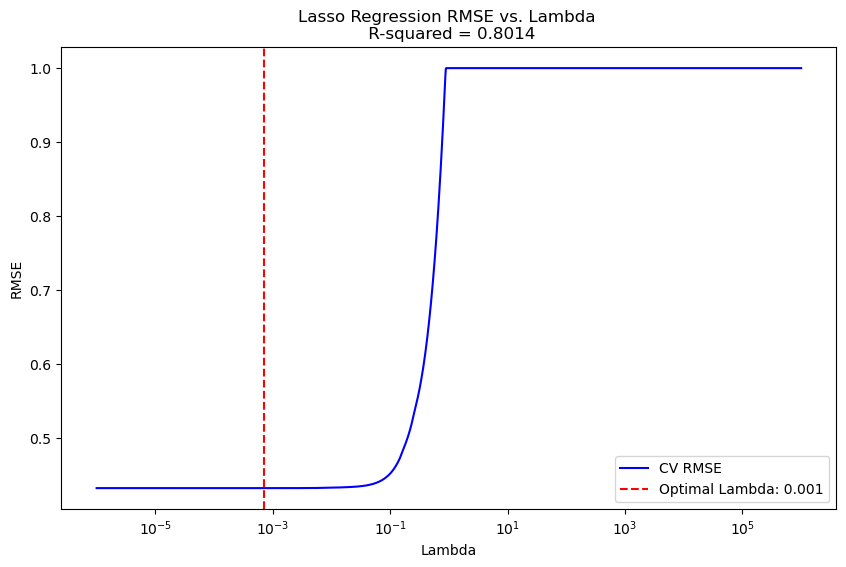

In [77]:
# Calculate the mean squared error from the cross-validation for each alpha
cv_mse_lasso = np.mean(lasso_cv.mse_path_, axis=1)

# Calculate the root mean squared error for visualization
cv_rmse_lasso = np.sqrt(cv_mse_lasso)

# Plotting RMSE vs. Lambda for Lasso
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, cv_rmse_lasso, label='CV RMSE', color='blue')
plt.xscale('log')  # Because alphas span several orders of magnitude
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha_lasso, color="red", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha_lasso, 3)}")
plt.title(f'Lasso Regression RMSE vs. Lambda \n R-squared = {round(r2_lasso_scaled,4)}')
plt.legend()
plt.show()


#### Approach (e): Ridge Regression
Out of (1) dropping the null values in `Take Again Proportion`, (2) imputing the null values, and (3) dropping the feature, dropping the null values resulted in the best evaluation metrics. Therefore, we are doing ridge regression with dropping the null values.

In [78]:
# Create a copy of the dataset to avoid overwriting the original and drop null (null values in take again proportion)

q7 = merged_df.copy().dropna()

# Define the outcome variable (target) and predictors
X = q7[["Bayesian Average Difficulty", "Number of Ratings",
        "Received Pepper", "Take Again Proportion", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Reshape y_train and y_test to be 2D arrays for scaling
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Standardizing features and outcome variable
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train_reshaped).flatten()  # Flatten back to 1D
y_test_scaled = scaler_y.transform(y_test_reshaped).flatten()

# Define a range of alphas
alphas = np.linspace(0.0001, 100, 201)

# Initialize RidgeCV with the defined alphas
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_scaled, y_train_scaled)

# Calculate cross-validated mean squared error (MSE)
cv_mse = np.mean(ridge_cv.cv_values_, axis=0)

# Calculate cross-validated root mean squared error (RMSE)
cv_rmse = np.sqrt(cv_mse)

# Display the optimal alpha
optimal_alpha = ridge_cv.alpha_
print(f"Optimal Lambda (Alpha): {round(optimal_alpha, 3)}")

# Predict on the test set using the Ridge model
y_pred_ridge = ridge_cv.predict(X_test_scaled)

# Calculate RMSE and R-squared for the Ridge Regression model
rmse_ridge = np.sqrt(mean_squared_error(y_test_scaled, y_pred_ridge))
r_squared_ridge = r2_score(y_test_scaled, y_pred_ridge)

print(f"RMSE for Ridge Regression: {round(rmse_ridge, 3)}")
print(f"R-squared for Ridge Regression: {round(r_squared_ridge, 3)}")

/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Optimal Lambda (Alpha): 2.5
RMSE for Ridge Regression: 0.433
R-squared for Ridge Regression: 0.813


/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:102: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


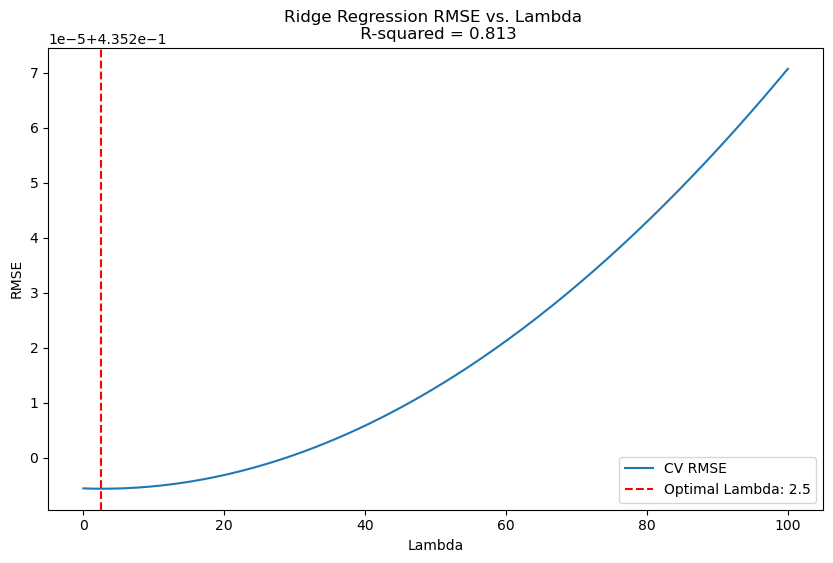

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_rmse.flatten(), label='CV RMSE')  # Use .flatten() to ensure cv_rmse is 1D
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha, color="r", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha,3)}")
plt.title(f'Ridge Regression RMSE vs. Lambda \n R-squared = {round(r_squared_ridge, 3)}')
plt.legend()
plt.show()


In [80]:
# Extract the beta coefficients from the trained Ridge model and ensure it's 1D
beta_coefficients = ridge_cv.coef_.flatten()

# Create a DataFrame with feature names and their corresponding beta coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Beta Coefficient': beta_coefficients
})

# Display the DataFrame
coefficients_df.sort_values(by = "Beta Coefficient", ascending=False)

,Feature,Beta Coefficient
3,Take Again Proportion,0.734224
2,Received Pepper,0.122037
5,Male,0.037865
6,Female,0.024255
4,Online Ratings,-0.000218
1,Number of Ratings,-0.004069
0,Bayesian Average Difficulty,-0.175162


#### Approach (f): Using only (Bayesian) Average Difficulty as a Feature

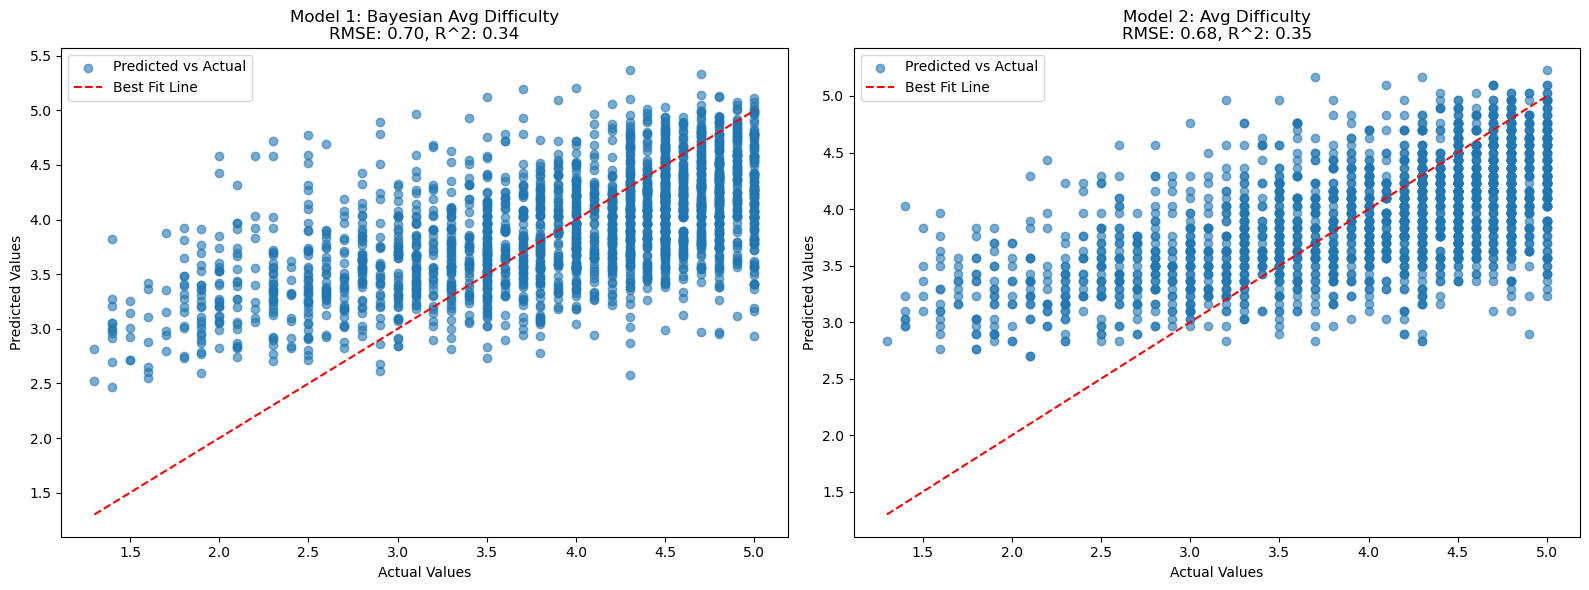

In [81]:
# Define a function to train a model and return RMSE, R^2, and predictions
def train_and_plot(q7, predictor, outcome, subplot_index, title):
    X = q7[[predictor]]
    y = q7[outcome]
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    
    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate RMSE and R^2
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Plot the scatter plot
    plt.subplot(1, 2, subplot_index)
    plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
    plt.title(f"{title}\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=12)
    plt.xlabel("Actual Values", fontsize=10)
    plt.ylabel("Predicted Values", fontsize=10)
    plt.legend(fontsize=10)

# Copy the dataset and drop missing values
q7 = merged_df.copy().dropna()

# Create the figure and subplots
plt.figure(figsize=(16, 6))

# Model 1: Bayesian Average Difficulty
train_and_plot(q7, "Bayesian Average Difficulty", "Average Rating", 1, "Model 1: Bayesian Avg Difficulty")

# Model 2: Average Difficulty
train_and_plot(q7, "Average Difficulty", "Average Rating", 2, "Model 2: Avg Difficulty")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [82]:
# Define the outcome variable (target) and predictors
# Drop the outcome variable and irrelevant columns to isolate predictors

q7 = merged_df.copy().dropna()

# Keep only rows where "Number of Ratings" > 4
q7 = q7[q7["Number of Ratings"] > 4]

X = q7[["Number of Ratings",
        "Received Pepper", "Take Again Proportion", "Online Ratings", "Male", "Female"]]

y = q7["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [83]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Add a column for the absolute value of the coefficients
df_coefficients['Absolute Coefficient'] = df_coefficients['Coefficient'].abs()

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)
df_coefficients['Absolute Coefficient'] = df_coefficients['Absolute Coefficient'].round(2)

# Sort the DataFrame by the absolute value of the coefficients
df_coefficients_sorted = df_coefficients.sort_values(by='Absolute Coefficient', ascending=False)

# Display the sorted DataFrame
df_coefficients_sorted

,Variable,Coefficient,Absolute Coefficient
0,Intercept,1.67,1.67
2,Received Pepper,0.22,0.22
5,Male,0.07,0.07
6,Female,0.05,0.05
3,Take Again Proportion,0.03,0.03
1,Number of Ratings,-0.00,0.00
4,Online Ratings,0.00,0.00


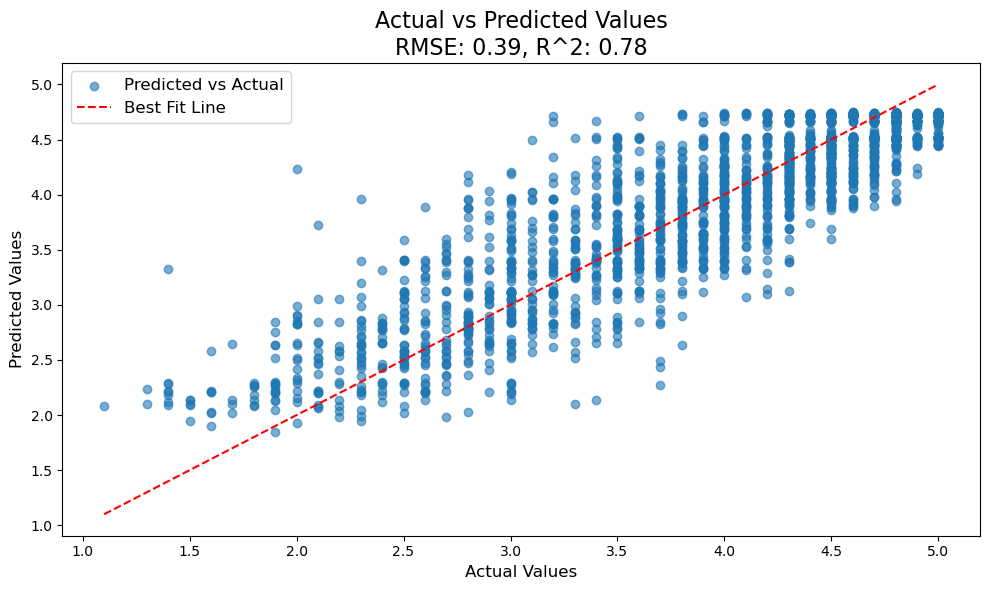

In [84]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Question 8: Regression
**Goal:** Build a regression model to predict average rating from all tags (the ones in the 
rmpCapstoneTags.csv)

### (a) Regression using all the tags
- We do not face the issue of missing values with the tags dataset. Note that the tags dataset is normalized based on number of ratings that a professor recieved

In [85]:
# Define the outcome variable (target) and predictors
# Drop the outcome variable and irrelevant columns to isolate predictors

q8 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q8 = q8[q8["Number of Ratings"] > 4]

X = q8.iloc[:,11:31]

y = q8["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

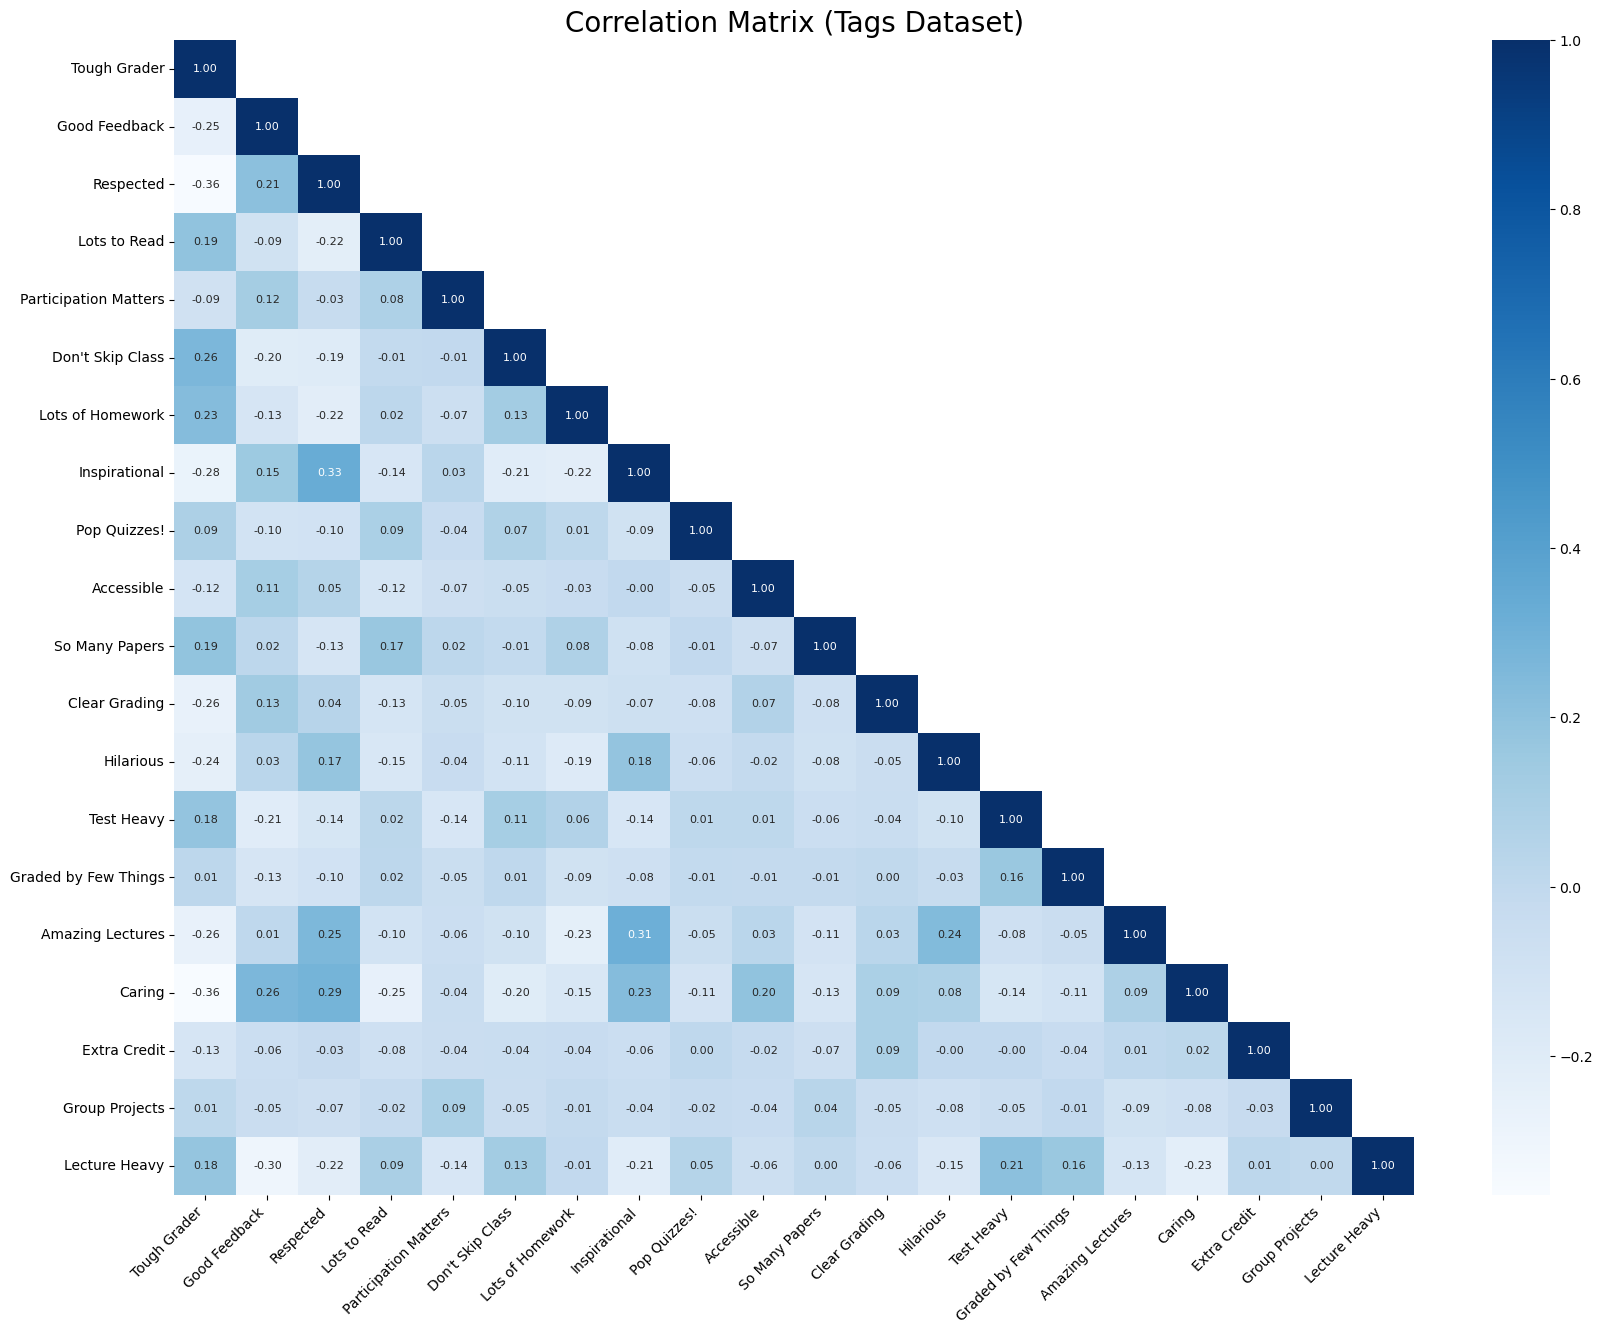

In [86]:
# Calculate the correlation matrix
correlation_matrix = X.corr()

# Generate a mask for the upper triangle without the diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

# Set the figure size
plt.figure(figsize=(20, 15))

# Create the heatmap with the mask
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cbar=True, cmap="Blues", annot_kws={'size': 8}, mask=mask)

# Add a title
plt.title('Correlation Matrix (Tags Dataset)', fontsize=20)

# Rotate x-axis and y-axis tick labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()

In [87]:
# Filter the correlations greater than or equal to 0.5
correlations = correlation_matrix.where(mask).stack().reset_index()

# Rename the columns
correlations.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Filter for correlations >= 0.4 or <= -0.4
strong_correlations = correlations[
    (correlations['Correlation'] >= 0.3) | (correlations['Correlation'] <= -0.3)
]

strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
1,Tough Grader,Respected,-0.355489
15,Tough Grader,Caring,-0.363999
41,Respected,Inspirational,0.331896
119,Inspirational,Amazing Lectures,0.309081


- Notice that the correlation between all the normalized tags do not exceed 0.2. Given the low correlation, we are not worries about multicollinearity

In [88]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)

# Display the DataFrame
df_coefficients.sort_values(by = "Coefficient", ascending = False)

,Variable,Coefficient
0,Intercept,2.93
16,Amazing Lectures,1.20
2,Good Feedback,1.01
3,Respected,1.01
12,Clear Grading,0.96
17,Caring,0.85
13,Hilarious,0.78
18,Extra Credit,0.62
10,Accessible,0.60
8,Inspirational,0.58


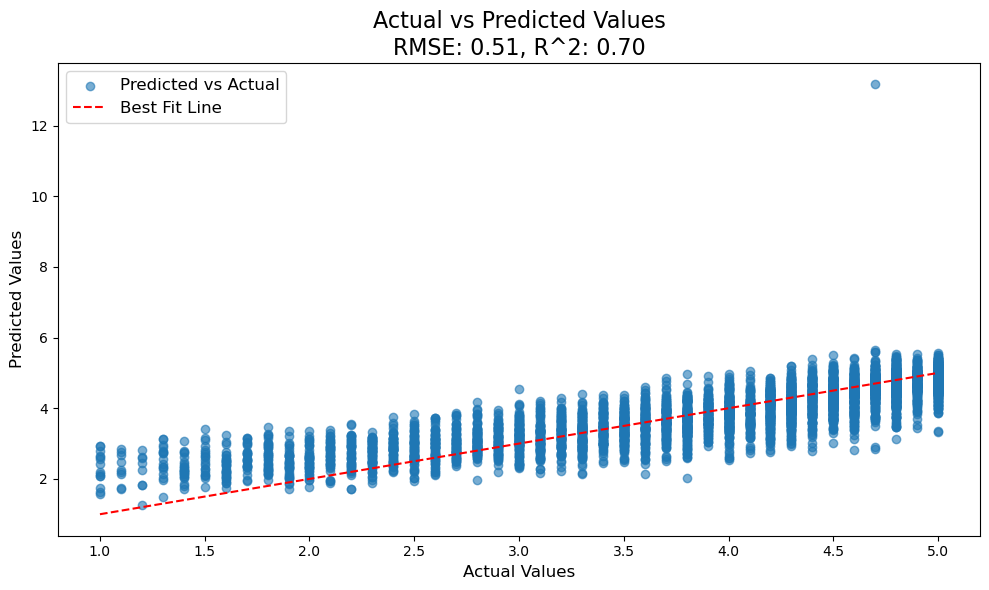

In [89]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### (b) Lasso Regression (Feature Selection)

In [90]:
# Create a copy of the dataset to avoid overwriting the original
q8 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q8 = q8[q8["Number of Ratings"] > 4]

# Define the outcome variable (target) and predictors
X = q8.iloc[:,11:31]

y = q8["Average Rating"]


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Standardizing the features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardizing the outcome variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Defining a range of alphas for Lasso
alphas = np.logspace(-6, 6, 1500)

# Initialize and fit LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=seed)
lasso_cv.fit(X_train_scaled, y_train_scaled)

# Find the optimal alpha
optimal_alpha_lasso = lasso_cv.alpha_

# Train the Lasso model with the optimal alpha
lasso = Lasso(alpha=optimal_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train_scaled)
y_pred_lasso_scaled = lasso.predict(X_test_scaled)

# Evaluate the Lasso model
r2_lasso_scaled = r2_score(y_test_scaled, y_pred_lasso_scaled)
rmse_lasso_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_lasso_scaled))

# Count the number of coefficients shrunk to zero
num_zero_coefs = np.sum(lasso.coef_ == 0)

# Print results
print(f"Optimal alpha (lambda) for Lasso: {round(optimal_alpha_lasso, 4)}")
print(f"R-squared for Lasso model (scaled outcome): {round(r2_lasso_scaled, 4)}")
print(f"RMSE for Lasso model (scaled outcome): {round(rmse_lasso_scaled, 4)}")
print(f"Number of predictors shrunk to zero: {num_zero_coefs}")

# Create a DataFrame of feature names and their corresponding Lasso coefficients
coefficients_lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_
})

# Sort the DataFrame by the absolute values of the coefficients
coefficients_lasso_df['Absolute Coefficient'] = coefficients_lasso_df['Lasso Coefficient'].abs()
coefficients_lasso_df.sort_values(by="Absolute Coefficient", ascending=False, inplace=True)
coefficients_lasso_df.drop(columns=["Absolute Coefficient"], inplace=True)

# Display the DataFrame
coefficients_lasso_df

Optimal alpha (lambda) for Lasso: 0.0021
R-squared for Lasso model (scaled outcome): 0.7128
RMSE for Lasso model (scaled outcome): 0.5289
Number of predictors shrunk to zero: 0


,Feature,Lasso Coefficient
0,Tough Grader,-0.244493
1,Good Feedback,0.233307
15,Amazing Lectures,0.194886
2,Respected,0.183421
16,Caring,0.176056
11,Clear Grading,0.148477
12,Hilarious,0.144565
17,Extra Credit,0.085529
7,Inspirational,0.083559
4,Participation Matters,0.071481


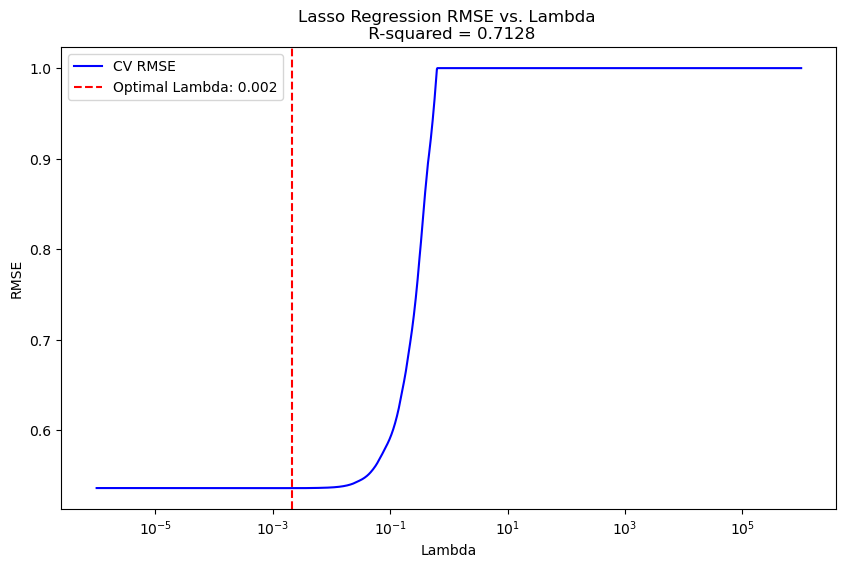

In [91]:
# Calculate the mean squared error from the cross-validation for each alpha
cv_mse_lasso = np.mean(lasso_cv.mse_path_, axis=1)

# Calculate the root mean squared error for visualization
cv_rmse_lasso = np.sqrt(cv_mse_lasso)

# Plotting RMSE vs. Lambda for Lasso
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, cv_rmse_lasso, label='CV RMSE', color='blue')
plt.xscale('log')  # Because alphas span several orders of magnitude
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha_lasso, color="red", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha_lasso, 3)}")
plt.title(f'Lasso Regression RMSE vs. Lambda \n R-squared = {round(r2_lasso_scaled,4)}')
plt.legend()
plt.show()


### (c) Ridge Regression

In [92]:
# Create a copy of the dataset to avoid overwriting the original
q8 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q8 = q8[q8["Number of Ratings"] > 4]

# Define the outcome variable (target) and predictors
X = q8.iloc[:,11:31]

y = q8["Average Rating"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Reshape y_train and y_test to be 2D arrays for scaling
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Standardizing features and outcome variable
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train_reshaped).flatten()  # Flatten back to 1D
y_test_scaled = scaler_y.transform(y_test_reshaped).flatten()

# Define a range of alphas
alphas = np.linspace(0.0001, 100, 201)

# Initialize RidgeCV with the defined alphas
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_scaled, y_train_scaled)

# Calculate cross-validated mean squared error (MSE)
cv_mse = np.mean(ridge_cv.cv_values_, axis=0)

# Calculate cross-validated root mean squared error (RMSE)
cv_rmse = np.sqrt(cv_mse)

# Display the optimal alpha
optimal_alpha = ridge_cv.alpha_
print(f"Optimal Lambda (Alpha): {round(optimal_alpha, 3)}")

# Predict on the test set using the Ridge model
y_pred_ridge = ridge_cv.predict(X_test_scaled)

# Calculate RMSE and R-squared for the Ridge Regression model
rmse_ridge = np.sqrt(mean_squared_error(y_test_scaled, y_pred_ridge))
r_squared_ridge = r2_score(y_test_scaled, y_pred_ridge)

print(f"RMSE for Ridge Regression: {round(rmse_ridge, 3)}")
print(f"R-squared for Ridge Regression: {round(r_squared_ridge, 3)}")

/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Optimal Lambda (Alpha): 100.0
RMSE for Ridge Regression: 0.531
R-squared for Ridge Regression: 0.71


/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:102: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


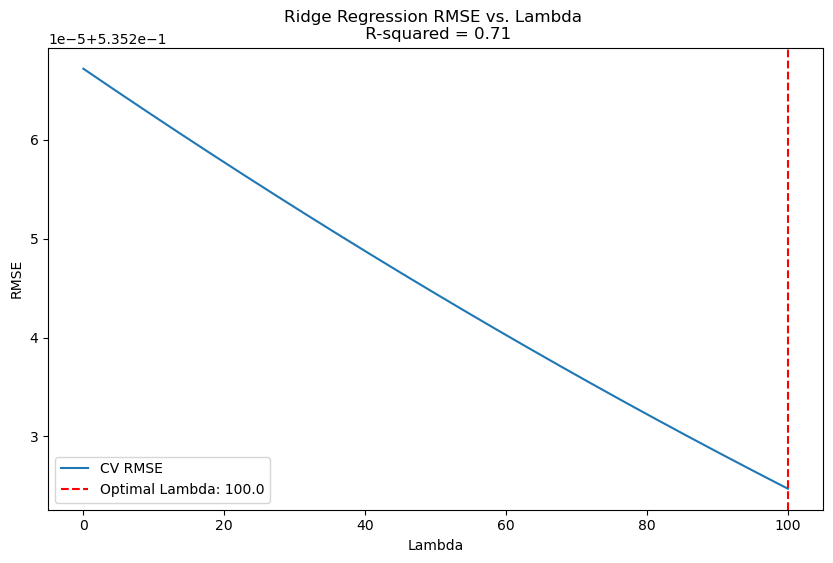

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_rmse.flatten(), label='CV RMSE')  # Use .flatten() to ensure cv_rmse is 1D
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha, color="r", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha,3)}")
plt.title(f'Ridge Regression RMSE vs. Lambda \n R-squared = {round(r_squared_ridge, 3)}')
plt.legend()
plt.show()


In [94]:
# Extract the beta coefficients from the trained Ridge model and ensure it's 1D
beta_coefficients = ridge_cv.coef_.flatten()

# Create a DataFrame with feature names and their corresponding beta coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Beta Coefficient': beta_coefficients
})

# Display the DataFrame
coefficients_df.sort_values(by = "Beta Coefficient", ascending=False)

,Feature,Beta Coefficient
1,Good Feedback,0.230521
15,Amazing Lectures,0.193231
2,Respected,0.184571
16,Caring,0.176649
11,Clear Grading,0.151630
12,Hilarious,0.145723
7,Inspirational,0.088113
17,Extra Credit,0.084793
4,Participation Matters,0.071868
9,Accessible,0.066773


# Question 9: Regression
**Goal:** Build a regression model to predict average difficulty from all tags (the ones in the 
rmpCapstoneTags.csv)

## (a) Regression using all tags

In [95]:
# Define the outcome variable (target) and predictors
# Drop the outcome variable and irrelevant columns to isolate predictors

q9 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q9 = q8[q8["Number of Ratings"] > 4]

X = q9.iloc[:,11:31]

y = q9["Average Difficulty"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE and R^2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

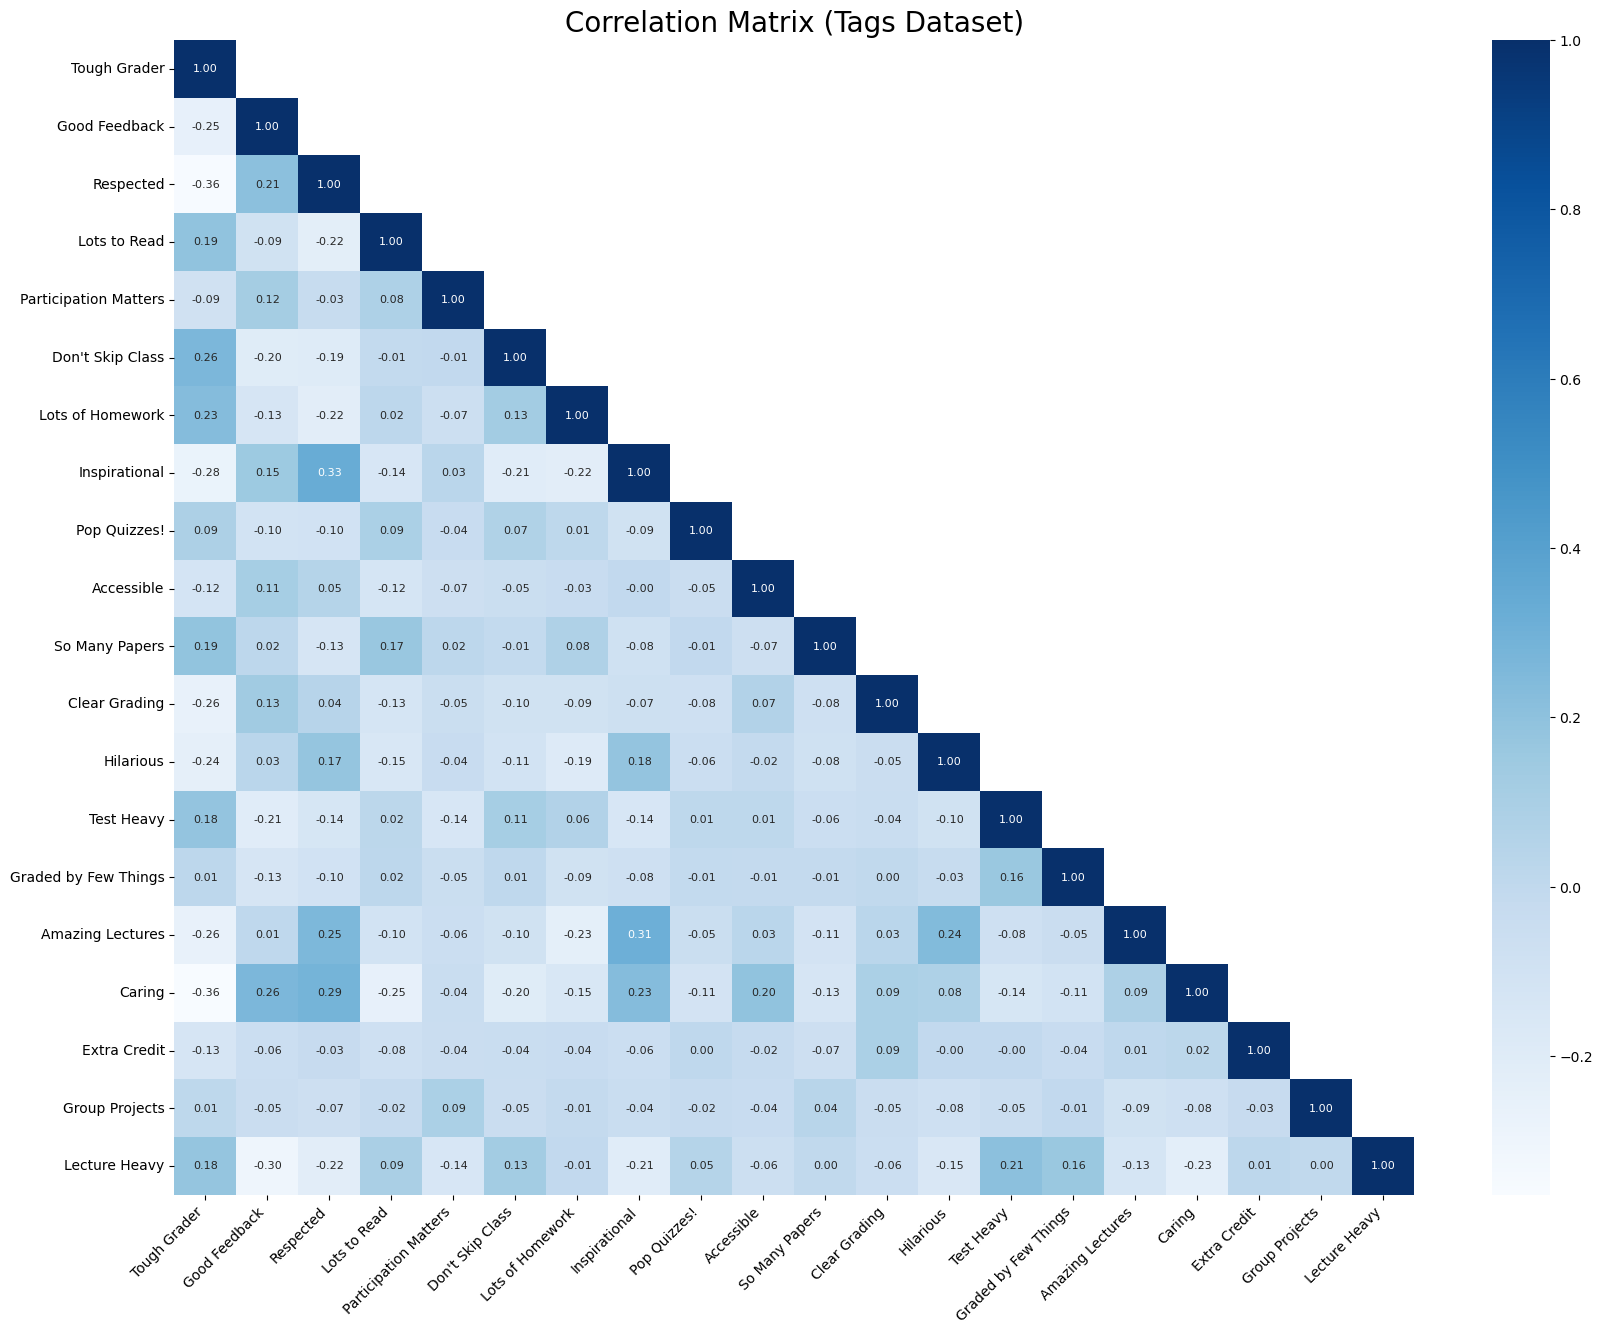

In [96]:
# Calculate the correlation matrix
correlation_matrix = X.corr()

# Generate a mask for the upper triangle without the diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

# Set the figure size
plt.figure(figsize=(20, 15))

# Create the heatmap with the mask
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cbar=True, cmap="Blues", annot_kws={'size': 8}, mask=mask)

# Add a title
plt.title('Correlation Matrix (Tags Dataset)', fontsize=20)

# Rotate x-axis and y-axis tick labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()

In [97]:
# Filter the correlations greater than or equal to 0.5
correlations = correlation_matrix.where(mask).stack().reset_index()

# Rename the columns
correlations.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Filter for correlations >= 0.5 or <= -0.5
strong_correlations = correlations[
    (correlations['Correlation'] >= 0.3) | (correlations['Correlation'] <= -0.3)
]

strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
1,Tough Grader,Respected,-0.355489
15,Tough Grader,Caring,-0.363999
41,Respected,Inspirational,0.331896
119,Inspirational,Amazing Lectures,0.309081


In [98]:
# Get feature names from X_train
variable_names = X_train.columns.tolist()

# Include 'Intercept' as the first variable name
variable_names = ['Intercept'] + variable_names

# Get the coefficients and include the intercept
coefficients = np.insert(model.coef_, 0, model.intercept_)

# Create a DataFrame for the coefficients
df_coefficients = pd.DataFrame({
    'Variable': variable_names,
    'Coefficient': coefficients
})

# Round the coefficients for better readability
df_coefficients['Coefficient'] = df_coefficients['Coefficient'].round(2)

# Display the DataFrame
df_coefficients.sort_values(by = "Coefficient", ascending = False)

,Variable,Coefficient
0,Intercept,2.59
1,Tough Grader,1.70
14,Test Heavy,1.23
10,Accessible,0.93
7,Lots of Homework,0.40
4,Lots to Read,0.39
6,Don't Skip Class,0.37
20,Lecture Heavy,0.20
9,Pop Quizzes!,0.15
11,So Many Papers,0.10


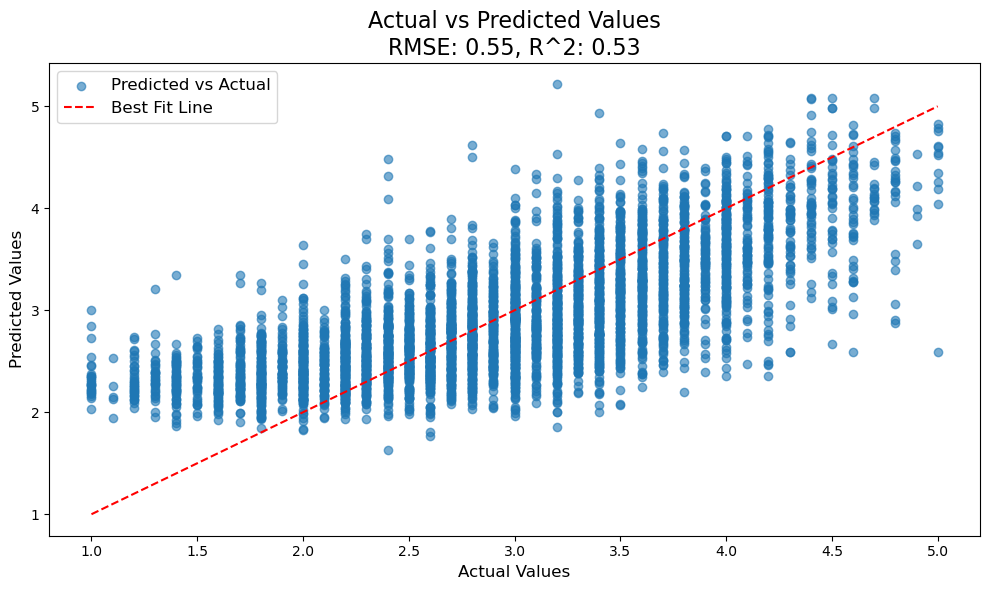

In [99]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Best Fit Line")
plt.title(f"Actual vs Predicted Values\nRMSE: {rmse:.2f}, R^2: {r2:.2f}", fontsize=16)
plt.xlabel("Actual Values", fontsize=12)
plt.ylabel("Predicted Values", fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## (b) Lasso Regression

In [100]:
# Create a copy of the dataset to avoid overwriting the original
q9 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q9 = q8[q8["Number of Ratings"] > 4]

X = q9.iloc[:,11:31]

y = q9["Average Difficulty"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Standardizing the features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardizing the outcome variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Defining a range of alphas for Lasso
alphas = np.logspace(-6, 6, 1500)

# Initialize and fit LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=seed)
lasso_cv.fit(X_train_scaled, y_train_scaled)

# Find the optimal alpha
optimal_alpha_lasso = lasso_cv.alpha_

# Train the Lasso model with the optimal alpha
lasso = Lasso(alpha=optimal_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train_scaled)
y_pred_lasso_scaled = lasso.predict(X_test_scaled)

# Evaluate the Lasso model
r2_lasso_scaled = r2_score(y_test_scaled, y_pred_lasso_scaled)
rmse_lasso_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_lasso_scaled))

# Count the number of coefficients shrunk to zero
num_zero_coefs = np.sum(lasso.coef_ == 0)

# Print results
print(f"Optimal alpha (lambda) for Lasso: {round(optimal_alpha_lasso, 4)}")
print(f"R-squared for Lasso model (scaled outcome): {round(r2_lasso_scaled, 4)}")
print(f"RMSE for Lasso model (scaled outcome): {round(rmse_lasso_scaled, 4)}")
print(f"Number of predictors shrunk to zero: {num_zero_coefs}")

# Create a DataFrame of feature names and their corresponding Lasso coefficients
coefficients_lasso_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_
})

# Sort the DataFrame by the absolute values of the coefficients
coefficients_lasso_df['Absolute Coefficient'] = coefficients_lasso_df['Lasso Coefficient'].abs()
coefficients_lasso_df.sort_values(by="Absolute Coefficient", ascending=False, inplace=True)
coefficients_lasso_df.drop(columns=["Absolute Coefficient"], inplace=True)

# Display the DataFrame
coefficients_lasso_df

Optimal alpha (lambda) for Lasso: 0.0012
R-squared for Lasso model (scaled outcome): 0.5431
RMSE for Lasso model (scaled outcome): 0.6621
Number of predictors shrunk to zero: 0


,Feature,Lasso Coefficient
0,Tough Grader,0.486563
9,Accessible,0.120203
13,Test Heavy,0.114137
6,Lots of Homework,0.100491
3,Lots to Read,0.098222
11,Clear Grading,-0.097663
12,Hilarious,-0.088331
5,Don't Skip Class,0.085989
16,Caring,-0.070990
17,Extra Credit,-0.064120


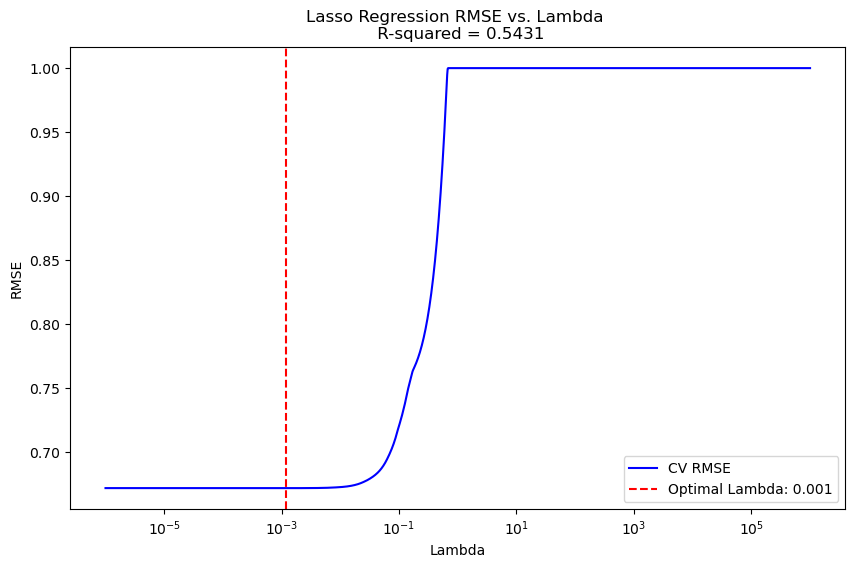

In [101]:
# Calculate the mean squared error from the cross-validation for each alpha
cv_mse_lasso = np.mean(lasso_cv.mse_path_, axis=1)

# Calculate the root mean squared error for visualization
cv_rmse_lasso = np.sqrt(cv_mse_lasso)

# Plotting RMSE vs. Lambda for Lasso
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv.alphas_, cv_rmse_lasso, label='CV RMSE', color='blue')
plt.xscale('log')  # Because alphas span several orders of magnitude
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha_lasso, color="red", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha_lasso, 3)}")
plt.title(f'Lasso Regression RMSE vs. Lambda \n R-squared = {round(r2_lasso_scaled,4)}')
plt.legend()
plt.show()


## (c) Ridge Regression

In [102]:
# Create a copy of the dataset to avoid overwriting the original
q9 = merged_df.copy()

# Set a threshold to keep rows with more than 4 ratings
q9 = q8[q8["Number of Ratings"] > 4]

X = q9.iloc[:,11:31]

y = q9["Average Difficulty"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Reshape y_train and y_test to be 2D arrays for scaling
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.values.reshape(-1, 1)

# Standardizing features and outcome variable
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train_reshaped).flatten()  # Flatten back to 1D
y_test_scaled = scaler_y.transform(y_test_reshaped).flatten()

# Define a range of alphas
alphas = np.linspace(0.0001, 100, 201)

# Initialize RidgeCV with the defined alphas
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_scaled, y_train_scaled)

# Calculate cross-validated mean squared error (MSE)
cv_mse = np.mean(ridge_cv.cv_values_, axis=0)

# Calculate cross-validated root mean squared error (RMSE)
cv_rmse = np.sqrt(cv_mse)

# Display the optimal alpha
optimal_alpha = ridge_cv.alpha_
print(f"Optimal Lambda (Alpha): {round(optimal_alpha, 3)}")

# Predict on the test set using the Ridge model
y_pred_ridge = ridge_cv.predict(X_test_scaled)

# Calculate RMSE and R-squared for the Ridge Regression model
rmse_ridge = np.sqrt(mean_squared_error(y_test_scaled, y_pred_ridge))
r_squared_ridge = r2_score(y_test_scaled, y_pred_ridge)

print(f"RMSE for Ridge Regression: {round(rmse_ridge, 3)}")
print(f"R-squared for Ridge Regression: {round(r_squared_ridge, 3)}")

/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Optimal Lambda (Alpha): 65.0
RMSE for Ridge Regression: 0.667
R-squared for Ridge Regression: 0.557


/Users/ghinaalshdaifat/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:102: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


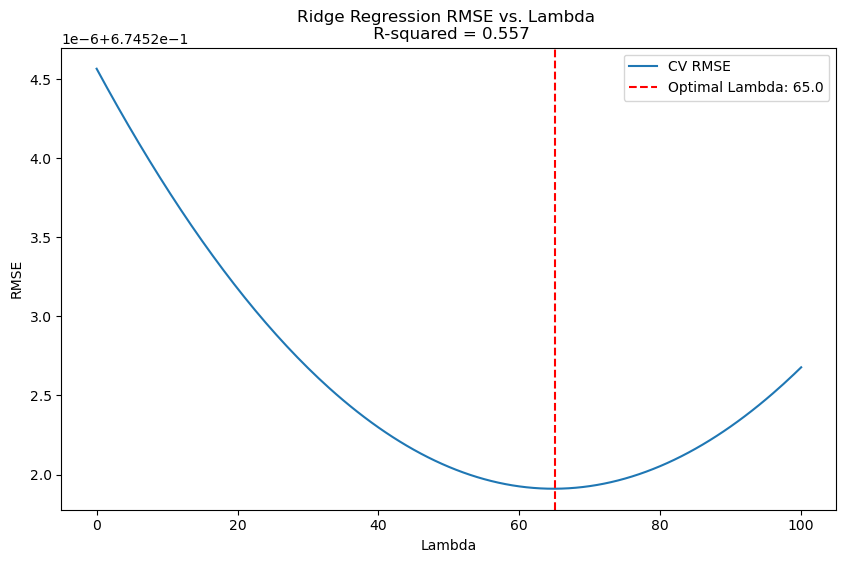

In [103]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_rmse.flatten(), label='CV RMSE')  # Use .flatten() to ensure cv_rmse is 1D
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.axvline(optimal_alpha, color="r", linestyle="--", label=f"Optimal Lambda: {round(optimal_alpha,3)}")
plt.title(f'Ridge Regression RMSE vs. Lambda \n R-squared = {round(r_squared_ridge, 3)}')
plt.legend()
plt.show()


In [104]:
# Extract the beta coefficients from the trained Ridge model and ensure it's 1D
beta_coefficients = ridge_cv.coef_.flatten()

# Create a DataFrame with feature names and their corresponding beta coefficients
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Beta Coefficient': beta_coefficients
})

# Display the DataFrame
coefficients_df.sort_values(by = "Beta Coefficient", ascending=False)

,Feature,Beta Coefficient
0,Tough Grader,0.482846
13,Test Heavy,0.116230
9,Accessible,0.114446
3,Lots to Read,0.100798
6,Lots of Homework,0.099416
5,Don't Skip Class,0.083757
19,Lecture Heavy,0.038312
8,Pop Quizzes!,0.021477
15,Amazing Lectures,0.016998
10,So Many Papers,0.006213


# Question 10: Classification Model
**Goal:**  Build a classification model that predicts whether a professor receives a “pepper” from all available factors(both tags and numerical). Make sure to include model quality metrics such as AU(RO)C and also address class imbalance concerns.

In [115]:
# Calculate the median of "Number of Ratings"
median_ratings = merged_df["Number of Ratings"].median()

# Filter the dataset to exclude entries with "Number of Ratings" below the median
q10 = merged_df[merged_df["Number of Ratings"] >= median_ratings]

In [116]:
def preprocess_data(q10, drop_nan=True, drop_column=False):
    """
    Preprocess data based on the specified method.
    """
    if drop_nan:
        # Drop rows with NaN in 'Take Again Proportion'
        q10 = q10.dropna(subset=["Take Again Proportion"])
    if drop_column:
        # Drop the 'Take Again Proportion' column entirely
        q10 = q10.drop(columns=["Take Again Proportion"])

    X = q10.drop(columns=["Average Rating", "Average Difficulty", "Received Pepper", "Major/Field", "University", "US State"])
    y = q10["Received Pepper"]
    return X, y

In [117]:
# Global list to store ROC-AUC curve data
roc_auc_data = []

In [118]:
def train_and_evaluate(X, y, model, model_name, pca=None):
    """
    Train and evaluate the classification model with metrics and plots.
    """
    global roc_auc_data

    # Address class imbalance using SMOTE
    smote = SMOTE(random_state=seed)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.2, random_state=seed
    )

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply PCA if specified
    if pca:
        pca_model = PCA(n_components=pca)
        X_train_scaled = pca_model.fit_transform(X_train_scaled)
        X_test_scaled = pca_model.transform(X_test_scaled)
        print(f"PCA Explained Variance Ratio for {model_name}: {pca_model.explained_variance_ratio_}")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions and probabilities
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Store ROC-AUC curve data
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    roc_auc_data.append((fpr, tpr, auc_score, model_name))

    # Print classification report
    print(f"\n------------------- Classification Report ({model_name}) -------------------")
    print(classification_report(y_test, y_pred))

In [119]:
def train_and_evaluate_linear_svc(X, y, model_name, pca=None):
    """
    Train and evaluate LinearSVC with optional PCA, metrics, and plots.
    """
    global roc_auc_data

    # Address class imbalance using SMOTE
    smote = SMOTE(random_state=12299542)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.2, random_state=12299542
    )

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply PCA if specified
    if pca:
        pca_model = PCA(n_components=pca)
        X_train_scaled = pca_model.fit_transform(X_train_scaled)
        X_test_scaled = pca_model.transform(X_test_scaled)
        print(f"PCA Explained Variance Ratio for {model_name}: {pca_model.explained_variance_ratio_}")

    # Train LinearSVC
    linear_svc = LinearSVC(random_state=12299542, class_weight="balanced", max_iter=1000)
    linear_svc.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = linear_svc.predict(X_test_scaled)

    # Decision function for ROC curve
    decision_values = linear_svc.decision_function(X_test_scaled)

    # Store ROC-AUC curve data
    fpr, tpr, thresholds = roc_curve(y_test, decision_values)
    auc_score = roc_auc_score(y_test, decision_values)
    roc_auc_data.append((fpr, tpr, auc_score, model_name))

    # Print classification report
    print(f"\n------------------- Classification Report ({model_name}) -------------------")
    print(classification_report(y_test, y_pred))

In [120]:
def get_optimal_pca_components(X, variance_threshold=0.95):
    """
    Determine the optimal number of PCA components based on explained variance.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_model = PCA().fit(X_scaled)
    explained_variance = np.cumsum(pca_model.explained_variance_ratio_)
    
    optimal_components = np.argmax(explained_variance >= variance_threshold) + 1
    print(f"Optimal number of PCA components for {variance_threshold*100}% variance: {optimal_components}")
    
    # Display explained variance ratio
    feature_importance_df = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
        "Cumulative Explained Variance": explained_variance
    })
    display(feature_importance_df)
    
    return optimal_components

In [121]:
# Plot all ROC-AUC curves
def plot_all_roc_curves(roc_auc_data):
    plt.figure(figsize=(10, 8))

    for fpr, tpr, auc_score, model_name in roc_auc_data:
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})")

    plt.plot([0, 1], [0, 1], "r--", label="Random Guess")
    plt.title("Combined ROC Curves for All Models", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()

In [122]:
# Models
log_reg = LogisticRegression(random_state=12299542, class_weight="balanced", max_iter=1000, solver="lbfgs")
linear_svc = LinearSVC(random_state=12299542, class_weight="balanced", max_iter=1000)

In [123]:
# Logistic Regression - Drop NaN
X_log_nan, y_log_nan = preprocess_data(q10.copy(), drop_nan=True, drop_column=False)
log_reg_nan = train_and_evaluate(X_log_nan, y_log_nan, log_reg, "Logistic Regression (Drop NaN)")


------------------- Classification Report (Logistic Regression (Drop NaN)) -------------------
              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72      1262
         1.0       0.71      0.75      0.73      1256

    accuracy                           0.73      2518
   macro avg       0.73      0.73      0.73      2518
weighted avg       0.73      0.73      0.73      2518



In [124]:
# Logistic Regression - Drop Column
X_log_col, y_log_col = preprocess_data(q10.copy(), drop_nan=False, drop_column=True)
log_reg_col = train_and_evaluate(X_log_col, y_log_col, log_reg, "Logistic Regression (Drop Column)")


------------------- Classification Report (Logistic Regression (Drop Column)) -------------------
              precision    recall  f1-score   support

         0.0       0.72      0.67      0.69      4841
         1.0       0.70      0.75      0.72      4979

    accuracy                           0.71      9820
   macro avg       0.71      0.71      0.71      9820
weighted avg       0.71      0.71      0.71      9820



In [125]:
# Linear SVC - Drop NaN
X_svc_nan, y_svc_nan = preprocess_data(q10.copy(), drop_nan=True, drop_column=False)
linear_svc_nan = train_and_evaluate_linear_svc(X_svc_nan, y_svc_nan, "Linear SVC (Drop NaN)")


------------------- Classification Report (Linear SVC (Drop NaN)) -------------------
              precision    recall  f1-score   support

         0.0       0.76      0.68      0.72      1252
         1.0       0.71      0.79      0.75      1266

    accuracy                           0.73      2518
   macro avg       0.74      0.73      0.73      2518
weighted avg       0.74      0.73      0.73      2518



In [126]:
# Linear SVC - Drop Column
X_svc_col, y_svc_col = preprocess_data(q10.copy(), drop_nan=False, drop_column=True)
linear_svc_col = train_and_evaluate_linear_svc(X_svc_col, y_svc_col, "Linear SVC (Drop Column)")


------------------- Classification Report (Linear SVC (Drop Column)) -------------------
              precision    recall  f1-score   support

         0.0       0.74      0.65      0.69      4914
         1.0       0.69      0.78      0.73      4906

    accuracy                           0.71      9820
   macro avg       0.72      0.71      0.71      9820
weighted avg       0.72      0.71      0.71      9820



In [131]:
# Get the optimal number of components
optimal_components = get_optimal_pca_components(X_log_nan, variance_threshold=0.95)

Optimal number of PCA components for 95.0% variance: 23


,PC,Cumulative Explained Variance
0,PC1,0.196061
1,PC2,0.270654
2,PC3,0.330716
3,PC4,0.384630
4,PC5,0.435488
5,PC6,0.479720
6,PC7,0.521528
7,PC8,0.561744
8,PC9,0.598217
9,PC10,0.634322


In [132]:
# Logistic Regression with PCA
X_log_pca, y_log_pca = preprocess_data(q10.copy(), drop_nan=True, drop_column=False)
log_reg_pca = train_and_evaluate(X_log_pca, y_log_pca, log_reg, "Logistic Regression with PCA", pca=optimal_components)

PCA Explained Variance Ratio for Logistic Regression with PCA: [0.19669171 0.07514125 0.06007964 0.05416339 0.05081392 0.04417072
 0.04168805 0.04048904 0.03658897 0.03574878 0.03192414 0.03164975
 0.03077319 0.02973809 0.02714484 0.02589057 0.02455504 0.02404812
 0.02204743 0.02189978 0.02115676 0.01951575 0.0156351 ]

------------------- Classification Report (Logistic Regression with PCA) -------------------
              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      1255
         1.0       0.72      0.76      0.74      1263

    accuracy                           0.73      2518
   macro avg       0.73      0.73      0.73      2518
weighted avg       0.73      0.73      0.73      2518



In [133]:
# Linear SVC with PCA
X_svc_pca, y_svc_pca = preprocess_data(q10.copy(), drop_nan=True, drop_column=False)
linear_svc_pca = train_and_evaluate_linear_svc(X_svc_pca, y_svc_pca, "Linear SVC with PCA", pca=optimal_components)

PCA Explained Variance Ratio for Linear SVC with PCA: [0.19723394 0.07446155 0.0606432  0.05402938 0.05044632 0.04398605
 0.0418008  0.04059549 0.03627585 0.03596969 0.03255407 0.03162284
 0.0308122  0.02987908 0.02693463 0.02602203 0.0242435  0.02387625
 0.02244651 0.02147694 0.02096062 0.01928391 0.01564796]

------------------- Classification Report (Linear SVC with PCA) -------------------
              precision    recall  f1-score   support

         0.0       0.74      0.67      0.70      1252
         1.0       0.70      0.76      0.73      1266

    accuracy                           0.72      2518
   macro avg       0.72      0.72      0.72      2518
weighted avg       0.72      0.72      0.72      2518



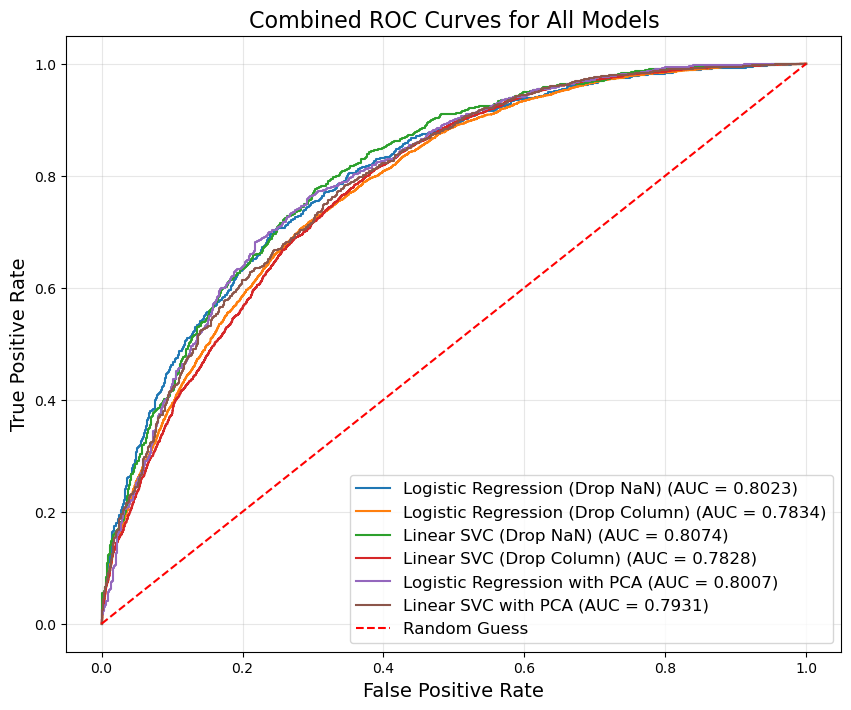

In [134]:
# Plot combined ROC-AUC curves
plot_all_roc_curves(roc_auc_data)

# Extra Credit: Clustering

In [135]:
# Import necesary libraries and packages
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import pairwise_distances
from scipy.stats import chi2_contingency

In [136]:
# Copy of the dataset
extra_credit = merged_df.copy()

# Calculate the median of "Number of Ratings"
median_ratings = extra_credit["Number of Ratings"].median()

# Filter the dataset to exclude entries with "Number of Ratings" below the median
extra_credit_df = extra_credit[extra_credit["Number of Ratings"] >= median_ratings]

In [137]:
# Copy of the dataset
extra_credit_df = merged_df.copy()

# Filter the DataFrame
major_counts = extra_credit_df["Major/Field"].value_counts()
filtered_df = extra_credit_df[extra_credit_df["Major/Field"].isin(major_counts[major_counts >= 100].index)].copy()

# Print number of majors after filtering
print(f"Number of majors with >= 100 entries: {filtered_df['Major/Field'].nunique()}")

Number of majors with >= 100 entries: 75


In [138]:
# Encode 'Major/Field' and 'University'
le_major = LabelEncoder()
le_university = LabelEncoder()

filtered_df["Major/Field_Encoded"] = le_major.fit_transform(filtered_df["Major/Field"])
filtered_df["University_Encoded"] = le_university.fit_transform(filtered_df["University"])

# Print sample encoded values
print("Sample Encoded Data:")
print(filtered_df[["Major/Field", "Major/Field_Encoded", "University", "University_Encoded"]].head())

Sample Encoded Data:
        Major/Field  Major/Field_Encoded                     University  \
0  Criminal Justice                   19        George Mason University   
2           English                   26       Alabama State University   
3           English                   26         University of Kentucky   
4           English                   26              Keiser University   
5           English                   26  Eastern Florida State College   

   University_Encoded  
0                 897  
2                  17  
3                2580  
4                1189  
5                 726  


In [139]:
# Standardize the encoded features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(filtered_df[["Major/Field_Encoded", "University_Encoded"]])

# Print shape after scaling
print(f"Shape after scaling: {X_scaled.shape}")

Shape after scaling: (58991, 2)


In [140]:
# Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=12299542)
clusters = kmeans.fit_predict(X_scaled)
filtered_df["Cluster"] = clusters

# Print number of professors per cluster
print("Number of Professors per Cluster:")
print(filtered_df["Cluster"].value_counts())

Number of Professors per Cluster:
Cluster
2    15805
0    14821
3    11429
4     8948
1     7988
Name: count, dtype: int64


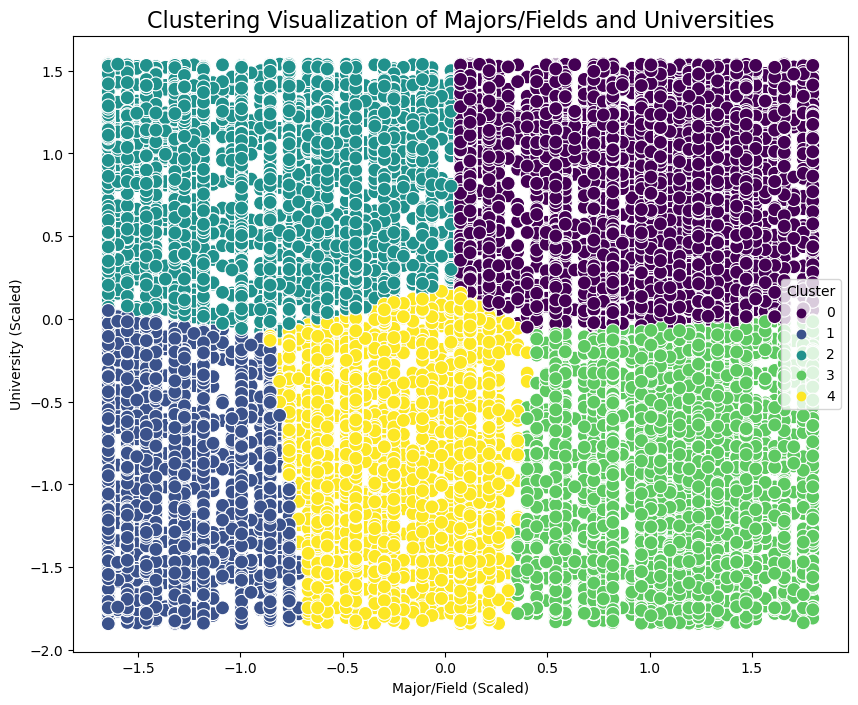

In [141]:
# Visualization of Clusters
filtered_df["X"] = X_scaled[:, 0]  # Major/Field
filtered_df["Y"] = X_scaled[:, 1]  # University

plt.figure(figsize=(10, 8))
sns.scatterplot(data=filtered_df, x="X", y="Y", hue="Cluster", palette="viridis", s=100)
plt.title("Clustering Visualization of Majors/Fields and Universities", fontsize=16)
plt.xlabel("Major/Field (Scaled)")
plt.ylabel("University (Scaled)")
plt.show()

In [142]:
# Calculate Pairwise Distances Between Clusters
cluster_centers = kmeans.cluster_centers_
distances = pairwise_distances(cluster_centers)

# Print Distance Matrix
print("Pairwise Distance Matrix Between Clusters:")
print(distances)

Pairwise Distance Matrix Between Clusters:
[[0.         2.83489839 1.81193582 1.8056932  2.1285515 ]
 [2.83489839 0.         1.84162257 2.29510904 0.92247736]
 [1.81193582 1.84162257 0.         2.63298941 1.79189424]
 [1.8056932  2.29510904 2.63298941 0.         1.38075418]
 [2.1285515  0.92247736 1.79189424 1.38075418 0.        ]]


In [143]:
# Find Farthest Clusters
farthest_clusters = np.unravel_index(np.argmax(distances), distances.shape)
print(f"Farthest Clusters: {farthest_clusters}")

Farthest Clusters: (0, 1)


In [144]:
# Extract Professors from Farthest Clusters
cluster_1_df = filtered_df[filtered_df["Cluster"] == farthest_clusters[0]]
cluster_2_df = filtered_df[filtered_df["Cluster"] == farthest_clusters[1]]

In [145]:
# Print Cluster Details
print(f"Sample Majors in Cluster {farthest_clusters[0]}:")
print(cluster_1_df["Major/Field"].value_counts().head())

print(f"\nSample Majors in Cluster {farthest_clusters[1]}:")
print(cluster_2_df["Major/Field"].value_counts().head())

Sample Majors in Cluster 0:
Major/Field
Mathematics    2820
Psychology     1656
History         811
Sociology       720
Nursing         627
Name: count, dtype: int64

Sample Majors in Cluster 1:
Major/Field
Biology             1690
Business            1208
Communication        978
Chemistry            954
Computer Science     844
Name: count, dtype: int64


In [146]:
# Investigate 'Received Pepper' in Original Data
cluster_1_profs = extra_credit_df[extra_credit_df["Major/Field"].isin(cluster_1_df["Major/Field"])]
cluster_2_profs = extra_credit_df[extra_credit_df["Major/Field"].isin(cluster_2_df["Major/Field"])]

In [147]:
# Count 'Received Pepper' for Both Clusters
pepper_counts_cluster_1 = cluster_1_profs["Received Pepper"].value_counts()
pepper_counts_cluster_2 = cluster_2_profs["Received Pepper"].value_counts()

# Print Pepper Counts
print("Received Pepper Counts (Cluster 1):")
print(pepper_counts_cluster_1, "\n")

print("Received Pepper Counts (Cluster 2):")
print(pepper_counts_cluster_2, "\n")

Received Pepper Counts (Cluster 1):
Received Pepper
0.0    20433
1.0     7938
Name: count, dtype: int64 

Received Pepper Counts (Cluster 2):
Received Pepper
0.0    12473
1.0     4724
Name: count, dtype: int64 



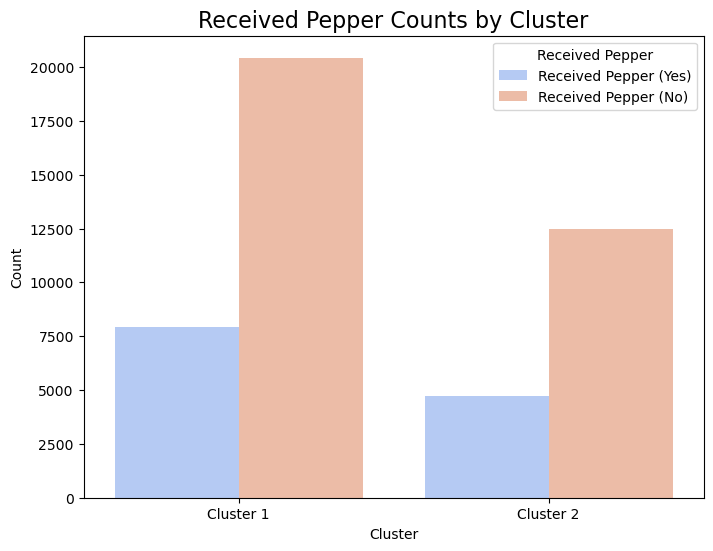

In [148]:
# Visualize Received Pepper Counts
counts_df = pd.DataFrame({
    "Cluster": ["Cluster 1", "Cluster 2"],
    "Received Pepper (Yes)": [
        pepper_counts_cluster_1.get(1.0, 0),
        pepper_counts_cluster_2.get(1.0, 0)
    ],
    "Received Pepper (No)": [
        pepper_counts_cluster_1.get(0.0, 0),
        pepper_counts_cluster_2.get(0.0, 0)
    ]
})

# Reshape for Seaborn Barplot
counts_df_melt = counts_df.melt(id_vars="Cluster", var_name="Received Pepper", value_name="Count")

# Plot 'Received Pepper' Counts
plt.figure(figsize=(8, 6))
sns.barplot(data=counts_df_melt, x="Cluster", y="Count", hue="Received Pepper", palette="coolwarm")
plt.title("Received Pepper Counts by Cluster", fontsize=16)
plt.show()

In [149]:
# Create a contingency table
contingency_table = pd.crosstab(filtered_df["Cluster"], filtered_df["Received Pepper"])

# Display the contingency table
print("--------------------Contingency Table:--------------------")
print(contingency_table)

# Perform the chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display test results
print("\n--------------------Chi-Squared Test Results:-----------------------")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p:.4e}")

# Interpret the p-value
alpha = 0.005 
if p < alpha:
    print("\nThe result is statistically significant. There is an association between Cluster and Received Pepper.")
else:
    print("\nThe result is NOT statistically significant. There is no evidence of an association between Cluster and Received Pepper.")

--------------------Contingency Table:--------------------
Received Pepper    0.0   1.0
Cluster                     
0                10777  4044
1                 5763  2225
2                11450  4355
3                 8134  3295
4                 6373  2575

--------------------Chi-Squared Test Results:-----------------------
Chi-Squared Statistic: 11.9449
Degrees of Freedom: 4
P-Value: 1.7765e-02

The result is NOT statistically significant. There is no evidence of an association between Cluster and Received Pepper.


In [150]:
# Print unique values for 'Major/Field'
unique_majors = filtered_df["Major/Field"].unique()
print(f"Unique Majors/Fields ({len(unique_majors)} total):")
print(unique_majors)

Unique Majors/Fields (75 total):
['Criminal Justice' 'English' 'Biology' 'Fine Arts' 'Computer Science'
 'Business' 'Management' 'Economics' 'Education' 'Nursing' 'Mathematics'
 'Spanish' 'Marketing' 'Psychology' 'Information Technology' 'History'
 'Humanities' 'Physical Education' 'Political Science' 'Sociology'
 'Engineering' 'Physics' 'Linguistics' 'Finance' 'Business Administration'
 'Hospitality' 'Biological Sciences' 'Music' 'Communication'
 "Women's Studies" 'Anthropology' 'Law' 'Chemistry' 'Journalism'
 'Health Science' 'Communication Studies' 'Science' 'Information Systems'
 'Philosophy' 'Writing' 'Art' 'Social Science' 'Languages'
 'Information Science' 'Literature' 'Geology' 'International Studies'
 'Government' 'Art History' 'Religion' 'Architecture' 'Foreign Languages'
 'Classics' 'Theater' 'Graphic Arts' 'Social Work'
 'Computer Information Systems' 'Geography' 'Mechanical Engineering'
 'Agriculture' 'Accounting' 'Statistics' 'Electrical Engineering'
 'Counseling' 'Speech

In [151]:
# Create a mapping dictionary
major_to_field = {
    # Sciences
    "Biology": "Sciences",
    "Physics": "Sciences",
    "Chemistry": "Sciences",
    "Mathematics": "Sciences",
    "Statistics": "Sciences",
    "Geology": "Sciences",
    "Biological Sciences": "Sciences",
    "Health Science": "Sciences",
    "Electrical Engineering": "Sciences",
    "Mechanical Engineering": "Sciences",
    "Civil Engineering": "Sciences",
    "Computer Science": "Sciences",
    "Information Technology": "Sciences",
    "Information Systems": "Sciences",
    "Computer Information Systems": "Sciences",
    "Environmental Science": "Sciences",
    "Kinesiology": "Sciences",
    "Science" : "Sciences",
    "Information Science" : "Sciences", 

    # Arts and Humanities
    "English": "Arts and Humanities",
    "Fine Arts": "Arts and Humanities",
    "Theater": "Arts and Humanities",
    "Art": "Arts and Humanities",
    "Music": "Arts and Humanities",
    "Art History": "Arts and Humanities",
    "Design": "Arts and Humanities",
    "Dance": "Arts and Humanities",
    "French": "Arts and Humanities",
    "Languages": "Arts and Humanities",
    "Literature": "Arts and Humanities",
    "Writing": "Arts and Humanities",
    "Philosophy": "Arts and Humanities",
    "History": "Arts and Humanities",
    "Religion": "Arts and Humanities",
    "Classics": "Arts and Humanities",
    "Theology": "Arts and Humanities",
    "Graphic Arts": "Arts and Humanities",
    "Spanish": "Arts and Humanities",
    "Humanities" : "Arts and Humanities", 
    "Architecture" : "Arts and Humanities",
    "Foreign Languages" : "Arts and Humanities",
    "Film" : "Arts and Humanities", 
    "English As A Second Language"  : "Arts and Humanities", 

    # Social Sciences
    "Psychology": "Social Sciences",
    "Sociology": "Social Sciences",
    "Political Science": "Social Sciences",
    "Anthropology": "Social Sciences",
    "Communication": "Social Sciences",
    "Social Work": "Social Sciences",
    "Social Science": "Social Sciences",
    "Linguistics": "Social Sciences",
    "Government": "Social Sciences",
    "International Studies": "Social Sciences",
    "Women's Studies": "Social Sciences",
    "Speech": "Social Sciences",
    "Communication Studies": "Social Sciences",
    "Geography": "Social Sciences", 

    # Professional Studies
    "Business": "Professional Studies",
    "Economics": "Professional Studies",
    "Management": "Professional Studies",
    "Marketing": "Professional Studies",
    "Finance": "Professional Studies",
    "Accounting": "Professional Studies",
    "Counseling": "Professional Studies",
    "Law": "Professional Studies",
    "Medicine": "Professional Studies",
    "Education": "Professional Studies",
    "Child Development": "Professional Studies",
    "Hospitality": "Professional Studies",
    "Physical Education": "Professional Studies",
    "Agriculture": "Professional Studies",
    "Journalism": "Professional Studies",
    "Criminal Justice": "Professional Studies",
    "Engineering": "Professional Studies",
    "Speech": "Professional Studies",
    'Nursing' : "Professional Studies", 
    "Business Administration" : "Professional Studies"
}

In [152]:
# Map 'Major/Field' to 'Broad Field'
filtered_df["Broad Field"] = filtered_df["Major/Field"].map(major_to_field)

In [153]:
# Check for missing mappings
missing_mappings = filtered_df[filtered_df["Broad Field"].isnull()]["Major/Field"].unique()
if len(missing_mappings) > 0:
    print(f"\nMajors without a mapping ({len(missing_mappings)} total):")
    print(missing_mappings)
else:
    print("\nAll majors have been mapped successfully.")


All majors have been mapped successfully.


In [154]:
# Print sample data with the new column
filtered_df[["Major/Field", "Cluster", "Broad Field", "Received Pepper"]].tail()

,Major/Field,Cluster,Broad Field,Received Pepper
89885,Psychology,0,Social Sciences,1.0
89888,Computer Science,2,Sciences,0.0
89889,Theater,0,Arts and Humanities,0.0
89890,Criminal Justice,2,Professional Studies,1.0
89891,French,2,Arts and Humanities,0.0


In [155]:
contingency_table_fields = pd.crosstab(filtered_df["Broad Field"], filtered_df["Received Pepper"])
contingency_table_fields

Received Pepper,0.0,1.0
Broad Field,,
Arts and Humanities,11764,5168
Professional Studies,11053,3447
Sciences,12682,4504
Social Sciences,6998,3375


In [156]:
# Perform the chi-squared test
chi2_field, p_field, dof_field, expected_field = chi2_contingency(contingency_table_fields)
# Display test results
print("\n--------------------Chi-Squared Test Results (Broad Fields):--------------------")
print(f"Chi-Squared Statistic: {chi2_field:.4f}")
print(f"Degrees of Freedom: {dof_field}")
print(f"P-Value: {p_field:.4e}")


--------------------Chi-Squared Test Results (Broad Fields):--------------------
Chi-Squared Statistic: 315.4789
Degrees of Freedom: 3
P-Value: 4.4404e-68


In [157]:
alpha = 0.005  # Significance level
if p_field < alpha:
    print("\nThe result is statistically significant. There is an association between Broad Field and Received Pepper.")
else:
    print("\nThe result is NOT statistically significant. There is no evidence of an association between Broad Field and Received Pepper.")


The result is statistically significant. There is an association between Broad Field and Received Pepper.


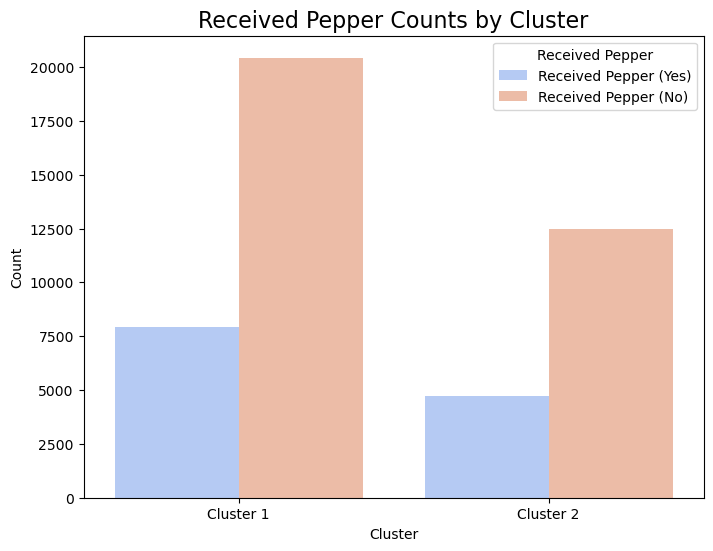

In [158]:
# Visualize Received Pepper Counts
counts_df = pd.DataFrame({
    "Cluster": ["Cluster 1", "Cluster 2"],
    "Received Pepper (Yes)": [
        pepper_counts_cluster_1.get(1.0, 0),
        pepper_counts_cluster_2.get(1.0, 0)
    ],
    "Received Pepper (No)": [
        pepper_counts_cluster_1.get(0.0, 0),
        pepper_counts_cluster_2.get(0.0, 0)
    ]
})

# Reshape for Seaborn Barplot
counts_df_melt = counts_df.melt(id_vars="Cluster", var_name="Received Pepper", value_name="Count")

# Plot 'Received Pepper' Counts
plt.figure(figsize=(8, 6))
sns.barplot(data=counts_df_melt, x="Cluster", y="Count", hue="Received Pepper", palette="coolwarm")
plt.title("Received Pepper Counts by Cluster", fontsize=16)
plt.show()

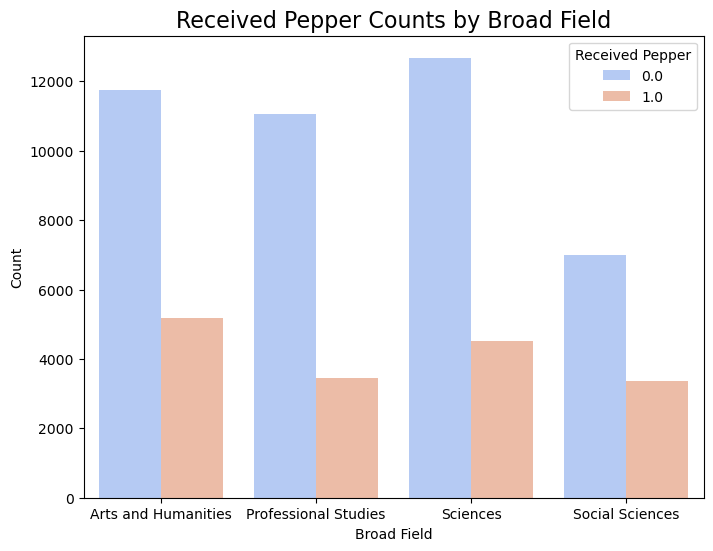

In [159]:
# Visualization of 'Received Pepper' Counts
broad_field_counts = pd.crosstab(filtered_df["Broad Field"], filtered_df["Received Pepper"]).reset_index()

# Reshape for Seaborn Barplot
broad_field_counts_melt = broad_field_counts.melt(id_vars="Broad Field", var_name="Received Pepper", value_name="Count")

# Plot 'Received Pepper' Counts
plt.figure(figsize=(8, 6))
sns.barplot(data=broad_field_counts_melt, x="Broad Field", y="Count", hue="Received Pepper", palette="coolwarm")
plt.title("Received Pepper Counts by Broad Field", fontsize=16)
plt.show()